In [1]:
# importation of liabries
import pandas as pd
import numpy as np
import sklearn

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
sns.set(style="darkgrid")
plt.rcParams['figure.figsize']=(10,10)

from datetime import timedelta
import datetime as dt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


In [2]:
# reading the train dataset
df_train = pd.read_csv("Train.csv")
df_train.head()

,id,site_id,site_latitude,site_longitude,city,country,date,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,...,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle,pm2_5
0,id_vjcx08sz91,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-10-25,13,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.015000
1,id_bkg215syli,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-02,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.267200
2,id_oui2pot3qd,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-03,13,NaN,NaN,...,6791.682888,51171.802486,5791.682829,11.816715,0.192757,-96.411890,61.045123,-121.307414,41.898269,39.450741
3,id_9aandqzy4n,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-08,14,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.537600
4,id_ali5x2m4iw,6531a46a89b3300013914a36,6.53257,3.39936,Lagos,Nigeria,2023-11-09,13,0.000267,0.774656,...,1451.050659,96215.906250,451.050598,10.521009,0.153114,-97.811241,49.513439,-126.064453,40.167355,19.431731


In [3]:
#reading the test data 
df_test = pd.read_csv("Test.csv")
df_test.head()


,id,site_id,site_latitude,site_longitude,city,country,date,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,...,cloud_cloud_top_pressure,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle
0,id_ihxgrbq8bw,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-06,13,-0.000072,0.762543,...,74217.403083,2710.544562,83569.504246,1710.544483,3.063105,0.263193,-100.317077,27.059646,-86.885670,25.530511
1,id_dg6s4fhiwe,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-07,13,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,id_f7hwwtmuzp,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-08,13,-0.000051,1.004265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,id_ioese5awdg,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-09,12,NaN,NaN,...,46052.449219,6585.034668,52160.980469,5585.034668,29.145922,0.314945,70.680077,61.874222,-90.875603,11.865201
4,id_hdw320zpls,64f9d17ab9e98d001ac9e882,5.61252,-0.22955,Accra,Ghana,2023-09-20,12,-0.000634,0.632173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#information of train data set having 8071 entries and total of 80 columns
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8071 entries, 0 to 8070
Data columns (total 80 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        8071 non-null   object 
 1   site_id                                                   8071 non-null   object 
 2   site_latitude                                             8071 non-null   float64
 3   site_longitude                                            8071 non-null   float64
 4   city                                                      8071 non-null   object 
 5   country                                                   8071 non-null   object 
 6   date                                                      8071 non-null   object 
 7   hour                                                      8071 non-null   int64  
 8   sulphurdioxide_so2

In [5]:
# information test dataset having 2783 entries and 79 columns in total
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 79 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        2783 non-null   object 
 1   site_id                                                   2783 non-null   object 
 2   site_latitude                                             2783 non-null   float64
 3   site_longitude                                            2783 non-null   float64
 4   city                                                      2783 non-null   object 
 5   country                                                   2783 non-null   object 
 6   date                                                      2783 non-null   object 
 7   hour                                                      2783 non-null   int64  
 8   sulphurdioxide_so2

In [6]:
#checking the total unique non value within the to dataset
df_train.isnull().sum().unique() |df_test.isnull().sum().unique()

array([   0, 5938, 3631, 5991, 4091,    5,  126, 8159, 3327])

In [7]:
# chechking the brief statistics of the train dataset
df_train.describe()

,site_latitude,site_longitude,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,sulphurdioxide_so2_slant_column_number_density,sulphurdioxide_cloud_fraction,sulphurdioxide_sensor_azimuth_angle,sulphurdioxide_sensor_zenith_angle,sulphurdioxide_solar_azimuth_angle,...,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle,pm2_5
count,8071.000000,8071.000000,8071.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,3159.000000,...,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,4994.000000,8071.000000
mean,0.635678,30.246982,10.877463,0.000024,0.687295,0.000013,0.126581,2.120939,38.671939,-92.912582,...,6089.449805,58478.947647,5105.978072,16.885186,0.255501,-18.952179,45.881380,-84.811978,28.708028,24.639296
std,2.154605,9.393151,0.815875,0.000354,0.142544,0.000220,0.094129,85.450554,18.964322,43.240479,...,2991.879500,18974.281900,2971.949265,27.547282,0.046204,85.873938,14.721454,40.627170,7.038309,24.878920
min,-3.459970,3.201510,10.000000,-0.000980,0.299364,-0.000696,0.000000,-107.710861,0.177093,-165.131509,...,521.378113,10752.090499,9.741494,1.458444,0.090547,-102.706078,2.996863,-159.058782,10.314990,1.200000
25%,0.288630,32.568643,10.000000,-0.000196,0.589849,-0.000137,0.038062,-98.911720,22.811537,-134.823883,...,3687.102253,43231.418685,2701.118575,5.612198,0.228117,-98.865659,37.901279,-125.371559,24.102775,13.270600
50%,0.332610,32.600480,11.000000,0.000012,0.669632,0.000007,0.123876,71.653160,42.564364,-95.848477,...,5389.787844,60432.792969,4389.787844,8.752905,0.257323,-97.477511,49.187592,-74.597511,29.002745,18.375400
75%,0.374653,32.641110,11.000000,0.000221,0.766817,0.000149,0.209070,74.110476,54.238408,-49.662067,...,8047.738159,74276.492371,7047.738159,14.794590,0.285948,72.814735,57.156175,-49.902340,33.929767,28.838400
max,6.595400,36.914272,14.000000,0.002024,1.607052,0.001101,0.299850,77.319656,66.234924,-22.250822,...,17287.677734,100909.219778,16287.677734,250.000002,0.417945,77.319656,66.238778,-22.251009,45.496395,456.193333


In [8]:
# chechking the brief statistics of the test dataset
df_test.describe()

,site_latitude,site_longitude,hour,sulphurdioxide_so2_column_number_density,sulphurdioxide_so2_column_number_density_amf,sulphurdioxide_so2_slant_column_number_density,sulphurdioxide_cloud_fraction,sulphurdioxide_sensor_azimuth_angle,sulphurdioxide_sensor_zenith_angle,sulphurdioxide_solar_azimuth_angle,...,cloud_cloud_top_pressure,cloud_cloud_top_height,cloud_cloud_base_pressure,cloud_cloud_base_height,cloud_cloud_optical_depth,cloud_surface_albedo,cloud_sensor_azimuth_angle,cloud_sensor_zenith_angle,cloud_solar_azimuth_angle,cloud_solar_zenith_angle
count,2783.000000,2783.000000,2783.000000,1709.000000,1709.000000,1709.000000,1709.000000,1709.000000,1709.000000,1709.000000,...,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000,1504.000000
mean,1.549512,28.547601,10.968020,0.000019,0.671654,0.000010,0.096423,-11.358700,40.219066,-86.105632,...,52628.887085,5915.129943,59255.860492,4942.499342,12.586550,0.263633,-17.920188,49.103404,-84.325586,29.873696
std,2.113084,12.401021,0.974542,0.000329,0.167967,0.000202,0.095916,86.509087,18.573421,42.787118,...,16364.796559,2776.317745,17733.478506,2747.013572,19.371130,0.048321,85.544172,13.314652,42.560791,7.017742
min,-0.140730,-0.260570,10.000000,-0.000991,0.377971,-0.000778,0.000000,-102.784803,2.652696,-165.526367,...,13716.184570,679.022522,16184.467773,26.373798,1.007213,0.029857,-102.704803,2.997329,-165.526291,10.053283
25%,-0.101823,32.300407,10.000000,-0.000175,0.570959,-0.000120,0.000000,-99.367859,27.834786,-129.742325,...,42113.936231,4039.221479,47643.058594,3066.322547,4.180227,0.231757,-98.452573,40.628867,-125.704384,24.512137
50%,-0.070787,34.752824,11.000000,-0.000003,0.633956,-0.000002,0.072231,70.071861,41.864498,-71.376900,...,53353.406351,5469.088823,59878.560547,4485.485268,6.996820,0.263927,-97.247214,53.075366,-68.727708,29.742252
75%,2.789675,34.762048,11.000000,0.000214,0.733701,0.000137,0.177193,73.238297,55.630920,-47.890350,...,63558.115715,7325.507324,71315.689494,6325.507324,12.644257,0.296649,72.467522,60.301841,-50.514651,35.600303
max,5.651470,34.803285,14.000000,0.002468,1.725046,0.001082,0.298844,77.055786,66.224426,-22.725188,...,93750.632813,14816.351563,100585.117188,13816.351563,168.980896,0.419126,75.903503,66.224319,-22.720990,42.295593


## Cleaning of Dataset 

In [9]:
df_train["cloud_cloud_fraction"] = df_train["cloud_cloud_fraction"].fillna("0.580")
df_train["cloud_cloud_top_pressure"] = df_train["cloud_cloud_top_pressure"].fillna("51850.47")
df_train["cloud_cloud_top_height"] = df_train["cloud_cloud_top_height"].fillna("6089.44")
df_train["cloud_cloud_base_height"] = df_train["cloud_cloud_base_height"].fillna("5105.97")
df_train["cloud_cloud_base_pressure"] = df_train["cloud_cloud_base_pressure"].fillna("58478.94")
df_train["cloud_sensor_azimuth_angle"] = df_train["cloud_sensor_azimuth_angle"].fillna("-84.95")
df_train["cloud_sensor_zenith_angle"] = df_train["cloud_sensor_zenith_angle"].fillna("45.88")
df_train["cloud_solar_zenith_angle"] = df_train["cloud_solar_zenith_angle"].fillna("28.70")
df_train["cloud_solar_azimuth_angle"] = df_train["cloud_solar_azimuth_angle"].fillna("84.81")
df_train["cloud_cloud_optical_depth"] = df_train["cloud_cloud_optical_depth"].fillna("16.88")
df_train["cloud_surface_albedo"] = df_train["cloud_surface_albedo"].fillna("0.255")
df_train["uvaerosollayerheight_aerosol_height"] = df_train["uvaerosollayerheight_aerosol_height"].fillna("2217.91")
df_train["uvaerosollayerheight_aerosol_pressure"] = df_train["uvaerosollayerheight_aerosol_pressure"].fillna("78611.50")
df_train["uvaerosollayerheight_aerosol_optical_depth"] = df_train["uvaerosollayerheight_aerosol_optical_depth"].fillna("1.880")
df_train["uvaerosollayerheight_sensor_zenith_angle"] = df_train["uvaerosollayerheight_sensor_zenith_angle"].fillna("35.95")
df_train["uvaerosollayerheight_sensor_azimuth_angle"] = df_train["uvaerosollayerheight_sensor_azimuth_angle"].fillna("-25.43")
df_train["uvaerosollayerheight_solar_zenith_angle"] = df_train["uvaerosollayerheight_solar_zenith_angle"].fillna("29.18")
df_train["formaldehyde_tropospheric_hcho_column_number_density"] = df_train["formaldehyde_tropospheric_hcho_column_number_density"].fillna("0.00017")
df_train["formaldehyde_tropospheric_hcho_column_number_density_amf"] = df_train["formaldehyde_tropospheric_hcho_column_number_density_amf"].fillna("1.046")
df_train["formaldehyde_hcho_slant_column_number_density"] = df_train["formaldehyde_hcho_slant_column_number_density"].fillna("0.00010")
df_train["formaldehyde_cloud_fraction"] = df_train["formaldehyde_cloud_fraction"].fillna("0.19")
df_train["formaldehyde_solar_zenith_angle"] = df_train["formaldehyde_solar_zenith_angle"].fillna("28.03")
df_train["formaldehyde_solar_azimuth_angle"] = df_train["formaldehyde_solar_azimuth_angle"].fillna("-92.36")
df_train["formaldehyde_sensor_zenith_angle"] = df_train["formaldehyde_sensor_zenith_angle"].fillna("40.21")
df_train["formaldehyde_sensor_azimuth_angle"] = df_train["formaldehyde_sensor_azimuth_angle"].fillna("-2.76")
df_train["uvaerosolindex_absorbing_aerosol_index"] = df_train["uvaerosolindex_absorbing_aerosol_index"].fillna("-0.446")
df_train["uvaerosolindex_sensor_altitude"] = df_train["uvaerosolindex_sensor_altitude"].fillna("829596.6")
df_train["uvaerosolindex_sensor_azimuth_angle"] = df_train["uvaerosolindex_sensor_azimuth_angle"].fillna("829596.6")
df_train["uvaerosolindex_sensor_zenith_angle"] = df_train["uvaerosolindex_sensor_zenith_angle"].fillna("41.38")
df_train["uvaerosolindex_solar_azimuth_angle"] = df_train["uvaerosolindex_solar_azimuth_angle"].fillna("-88.90")
df_train["uvaerosolindex_solar_zenith_angle"] = df_train["uvaerosolindex_solar_zenith_angle"].fillna("28.38")
df_train["ozone_o3_column_number_density"] = df_train["ozone_o3_column_number_density"].fillna("0.117")
df_train["ozone_o3_column_number_density_amf"] = df_train["ozone_o3_column_number_density_amf"].fillna("2.65")
df_train["ozone_o3_slant_column_number_density"] = df_train["ozone_o3_slant_column_number_density"].fillna("0.31")
df_train["ozone_o3_effective_temperature"] = df_train["ozone_o3_effective_temperature"].fillna("228.2")
df_train["ozone_cloud_fraction"] = df_train["ozone_cloud_fraction"].fillna("0.51")
df_train["ozone_sensor_azimuth_angle"] = df_train["ozone_sensor_azimuth_angle"].fillna("-13.30")
df_train["ozone_sensor_zenith_angle"] = df_train["ozone_sensor_zenith_angle"].fillna("41.29")
df_train["ozone_solar_azimuth_angle"] = df_train["ozone_solar_azimuth_angle"].fillna("-88.65")
df_train["ozone_solar_zenith_angle"] = df_train["ozone_solar_zenith_angle"].fillna("28.54")

In [10]:
df_train["sulphurdioxide_so2_column_number_density"] = df_train["sulphurdioxide_so2_column_number_density"].fillna("2.40")
df_train["sulphurdioxide_so2_column_number_density_amf"] = df_train["sulphurdioxide_so2_column_number_density_amf"].fillna("2.40")
df_train["sulphurdioxide_so2_slant_column_number_density"] = df_train["sulphurdioxide_so2_slant_column_number_density"].fillna("1.255")
df_train["sulphurdioxide_cloud_fraction"] = df_train["sulphurdioxide_cloud_fraction"].fillna("0.126")
df_train["sulphurdioxide_sensor_azimuth_angle"] = df_train["sulphurdioxide_sensor_azimuth_angle"].fillna("2.12")
df_train["sulphurdioxide_sensor_zenith_angle"] = df_train["sulphurdioxide_sensor_zenith_angle"].fillna("38.67")
df_train["sulphurdioxide_solar_azimuth_angle"] = df_train["sulphurdioxide_solar_azimuth_angle"].fillna("-92.91")
df_train["sulphurdioxide_solar_zenith_angle"] = df_train["sulphurdioxide_solar_zenith_angle"].fillna("27.70")
df_train["sulphurdioxide_so2_column_number_density_15km"] = df_train["sulphurdioxide_so2_column_number_density_15km"].fillna("3.80")
df_train["carbonmonoxide_co_column_number_density"] = df_train["carbonmonoxide_co_column_number_density"].fillna("0.038")
df_train["carbonmonoxide_h2o_column_number_density"] = df_train["carbonmonoxide_h2o_column_number_density"].fillna("2200.21")
df_train["carbonmonoxide_cloud_height"] = df_train["carbonmonoxide_cloud_height"].fillna("2041.46")
df_train["carbonmonoxide_sensor_altitude"] = df_train["carbonmonoxide_sensor_altitude"].fillna("829573.19")
df_train["carbonmonoxide_sensor_azimuth_angle"] = df_train["carbonmonoxide_sensor_azimuth_angle"].fillna("-8.06")
df_train["carbonmonoxide_sensor_zenith_angle"] = df_train["carbonmonoxide_sensor_zenith_angle"].fillna("38.48")
df_train["nitrogendioxide_no2_column_number_density"] = df_train["nitrogendioxide_no2_column_number_density"].fillna("7.36e-05")
df_train["nitrogendioxide_stratospheric_no2_column_number_density"] = df_train["nitrogendioxide_stratospheric_no2_column_number_density"].fillna("3.32e-05")
df_train["nitrogendioxide_no2_slant_column_number_density"] = df_train["nitrogendioxide_no2_slant_column_number_density"].fillna("0.00012")
df_train["nitrogendioxide_tropopause_pressure"] = df_train["nitrogendioxide_tropopause_pressure"].fillna("8836.36")
df_train["nitrogendioxide_absorbing_aerosol_index"] = df_train["nitrogendioxide_absorbing_aerosol_index"].fillna("-0.36")
df_train["nitrogendioxide_sensor_altitude"] = df_train["nitrogendioxide_sensor_altitude"].fillna("829581.67")
df_train["nitrogendioxide_sensor_azimuth_angle"] = df_train["nitrogendioxide_sensor_azimuth_angle"].fillna("829581.67")
df_train["nitrogendioxide_sensor_zenith_angle"] = df_train["nitrogendioxide_sensor_zenith_angle"].fillna("37.299")
df_train["nitrogendioxide_solar_azimuth_angle"] = df_train["nitrogendioxide_solar_azimuth_angle"].fillna("37.299")
df_train["nitrogendioxide_solar_zenith_angle"] = df_train["nitrogendioxide_solar_zenith_angle"].fillna("28.80")
df_train["carbonmonoxide_solar_azimuth_angle"] = df_train["carbonmonoxide_solar_azimuth_angle"].fillna("-91.50")
df_train["uvaerosollayerheight_solar_azimuth_angle"] = df_train["uvaerosollayerheight_solar_azimuth_angle"].fillna("-81.18")
df_train["nitrogendioxide_tropospheric_no2_column_number_density"] = df_train["nitrogendioxide_tropospheric_no2_column_number_density"].fillna("4.04")




In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8071 entries, 0 to 8070
Data columns (total 80 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        8071 non-null   object 
 1   site_id                                                   8071 non-null   object 
 2   site_latitude                                             8071 non-null   float64
 3   site_longitude                                            8071 non-null   float64
 4   city                                                      8071 non-null   object 
 5   country                                                   8071 non-null   object 
 6   date                                                      8071 non-null   object 
 7   hour                                                      8071 non-null   int64  
 8   sulphurdioxide_so2

In [12]:
for column in df_test.columns:
    if 'zone' in column:
        df_test[column].fillna(df_test[column].mean(), inplace=True)

In [13]:
for column in df_test.columns:
    if 'cloud' in column:
         df_test[column].fillna(df_test[column].mean(), inplace=True)
       

In [14]:
for column in df_test.columns:
    if 'sulphurdioxide' in column:
         df_test[column].fillna(df_test[column].mode(1)[0], inplace=True)
 

In [15]:
for column in df_test.columns:
    if 'nitrogendioxide' in column:
         df_test[column].fillna(df_test[column].mode(1)[0], inplace=True)


In [16]:
for column in df_test.columns:
    if 'carbonmonoxide' in column:
         df_test[column].fillna(df_test[column].mode(1)[0], inplace=True)


In [17]:
for column in df_test.columns:
    if 'uvaerosollayerheight' in column:
        df_test.drop([column],axis=1,inplace=True)

In [18]:
for column in df_train.columns:
    if 'uvaerosollayerheight' in column:
        df_train.drop([column],axis=1,inplace=True)

In [19]:
mean_value= df_test["carbonmonoxide_solar_zenith_angle"].mean()
print(mean_value)

26.63595464673243


In [20]:

df_test["formaldehyde_tropospheric_hcho_column_number_density"] = df_test["formaldehyde_tropospheric_hcho_column_number_density"].fillna("1.0313")
df_test["formaldehyde_tropospheric_hcho_column_number_density_amf"] = df_test["formaldehyde_tropospheric_hcho_column_number_density_amf"].fillna("1.0313")
df_test["formaldehyde_hcho_slant_column_number_density"] = df_test["formaldehyde_hcho_slant_column_number_density"].fillna("8.394")
df_test["formaldehyde_cloud_fraction"] = df_test["formaldehyde_cloud_fraction"].fillna("0.143")
df_test["formaldehyde_solar_zenith_angle"] = df_test["formaldehyde_solar_zenith_angle"].fillna("29.85")
df_test["formaldehyde_solar_azimuth_angle"] = df_test["formaldehyde_solar_azimuth_angle"].fillna("-86.28")
df_test["formaldehyde_solar_zenith_angle"] = df_test["formaldehyde_solar_zenith_angle"].fillna("29.85")
df_test["formaldehyde_sensor_zenith_angle"] = df_test["formaldehyde_sensor_zenith_angle"].fillna("41.62")
df_test["formaldehyde_sensor_azimuth_angle"] = df_test["formaldehyde_sensor_azimuth_angle"].fillna("-12.366")
df_test["uvaerosolindex_absorbing_aerosol_index"] = df_test["uvaerosolindex_absorbing_aerosol_index"].fillna("0.436")
df_test["uvaerosolindex_sensor_azimuth_angle"] = df_test["uvaerosolindex_sensor_azimuth_angle"].fillna("41.86")
df_test["uvaerosolindex_sensor_zenith_angle"] = df_test["uvaerosolindex_sensor_zenith_angle"].fillna("41.86")
df_test["uvaerosolindex_solar_azimuth_angle"] = df_test["uvaerosolindex_solar_azimuth_angle"].fillna("-87.86")
df_test["uvaerosolindex_solar_zenith_angle"] = df_test["uvaerosolindex_solar_zenith_angle"].fillna("29.66")
df_test["carbonmonoxide_co_column_number_density"] = df_test["carbonmonoxide_co_column_number_density"].fillna("0.032")
df_test["carbonmonoxide_h2o_column_number_density"] = df_test["carbonmonoxide_h2o_column_number_density"].fillna("2337.02")
df_test["carbonmonoxide_sensor_altitude"] = df_test["carbonmonoxide_cloud_height"].fillna("2001.19")
df_test["carbonmonoxide_sensor_altitude"] = df_test["carbonmonoxide_sensor_altitude"].fillna("829429.25")
df_test["carbonmonoxide_sensor_azimuth_angle"] = df_test["carbonmonoxide_sensor_azimuth_angle"].fillna("-12.32")
df_test["carbonmonoxide_solar_azimuth_angle"] = df_test["carbonmonoxide_solar_azimuth_angle"].fillna("-12.32")

df_test["nitrogendioxide_no2_column_number_density"] = df_test["nitrogendioxide_no2_column_number_density"].fillna("5.26e-05")
df_test["nitrogendioxide_tropospheric_no2_column_number_density"] = df_test["nitrogendioxide_tropospheric_no2_column_number_density"].fillna("1.84e-05")
df_test["carbonmonoxide_sensor_altitude"] = df_test["carbonmonoxide_sensor_altitude"].fillna("829429.25")
df_test["nitrogendioxide_stratospheric_no2_column_number_density"] = df_test["nitrogendioxide_stratospheric_no2_column_number_density"].fillna("3.432e-05")
df_test["nitrogendioxide_no2_slant_column_number_density"] = df_test["nitrogendioxide_no2_slant_column_number_density"].fillna("0.000110")
df_test["nitrogendioxide_tropopause_pressure"] = df_test["nitrogendioxide_tropopause_pressure"].fillna("9060.61")
df_test["nitrogendioxide_absorbing_aerosol_index"] = df_test["nitrogendioxide_absorbing_aerosol_index"].fillna("-0.39")
df_test["nitrogendioxide_cloud_fraction"] = df_test["nitrogendioxide_cloud_fraction"].fillna("0.056")
df_test["nitrogendioxide_sensor_altitude"] = df_test["nitrogendioxide_sensor_altitude"].fillna("829502.21")
df_test["nitrogendioxide_sensor_zenith_angle"] = df_test["nitrogendioxide_sensor_zenith_angle"].fillna("39.75")
df_test["nitrogendioxide_no2_slant_column_number_density"] = df_test["nitrogendioxide_no2_slant_column_number_density"].fillna("0.000110")
df_test["nitrogendioxide_solar_azimuth_angle"] = df_test["nitrogendioxide_solar_azimuth_angle"].fillna("-86.91")
df_test["nitrogendioxide_solar_zenith_angle"] = df_test["nitrogendioxide_solar_zenith_angle"].fillna("2.21")
df_test["nitrogendioxide_tropospheric_no2_column_number_density"] = df_test["nitrogendioxide_tropospheric_no2_column_number_density"].fillna("1.87")
df_test["sulphurdioxide_so2_column_number_density_amf"] = df_test["sulphurdioxide_so2_column_number_density_amf"].fillna("0.67")
df_test["sulphurdioxide_so2_slant_column_number_density"] = df_test["sulphurdioxide_so2_slant_column_number_density"].fillna("9.86")
df_test["sulphurdioxide_cloud_fraction"] = df_test["sulphurdioxide_cloud_fraction"].fillna("0.096")
df_test["sulphurdioxide_sensor_azimuth_angle"] = df_test["sulphurdioxide_sensor_azimuth_angle"].fillna("-11.35")
df_test["sulphurdioxide_sensor_zenith_angle"] = df_test["sulphurdioxide_sensor_zenith_angle"].fillna("-11.35")
df_test["sulphurdioxide_sensor_zenith_angle"] = df_test["sulphurdioxide_sensor_zenith_angle"].fillna("40.21")
df_test["sulphurdioxide_so2_column_number_density_15km"] = df_test["sulphurdioxide_so2_column_number_density_15km"].fillna("2.21")
df_train["carbonmonoxide_solar_zenith_angle"] = df_train["carbonmonoxide_solar_zenith_angle"].fillna("29.78")
df_train["nitrogendioxide_cloud_fraction"] = df_train["nitrogendioxide_cloud_fraction"].fillna("0.081")


<Axes: >

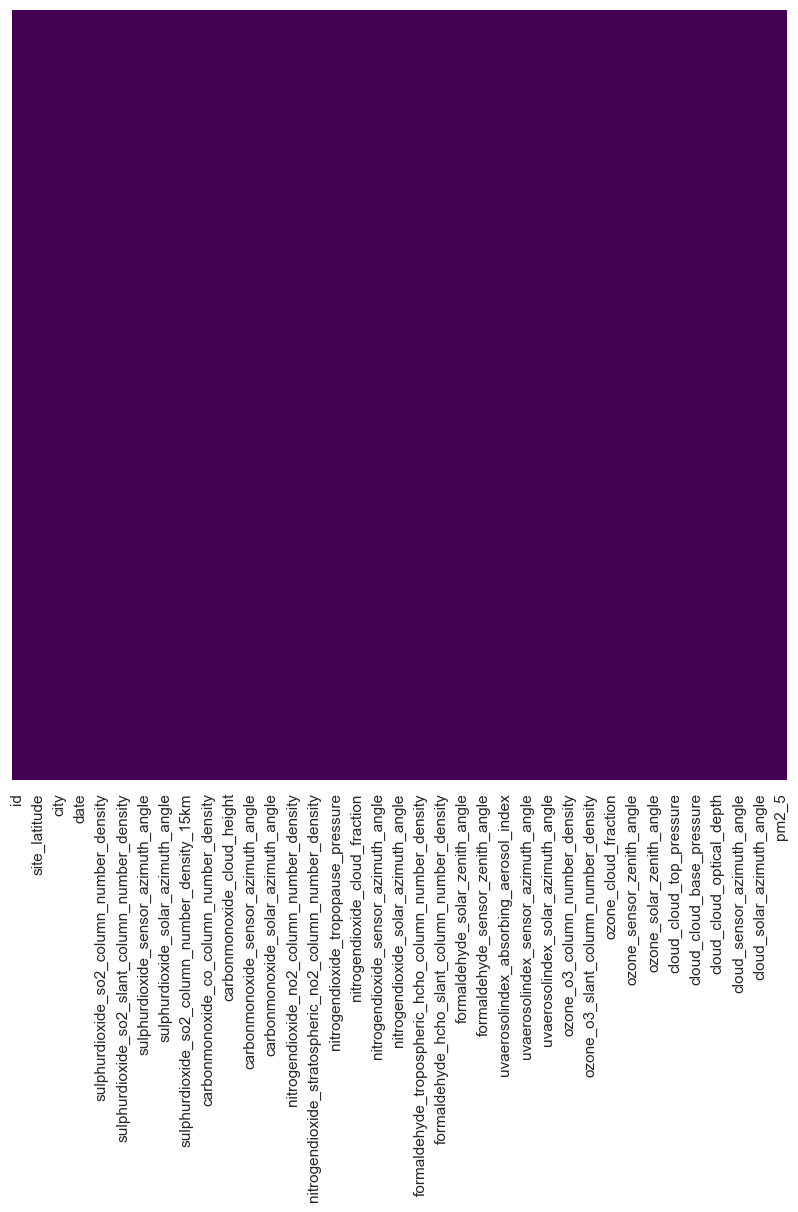

In [21]:
sns.heatmap(df_train.isnull(), yticklabels =False ,cbar =False , cmap ="viridis")

<Axes: >

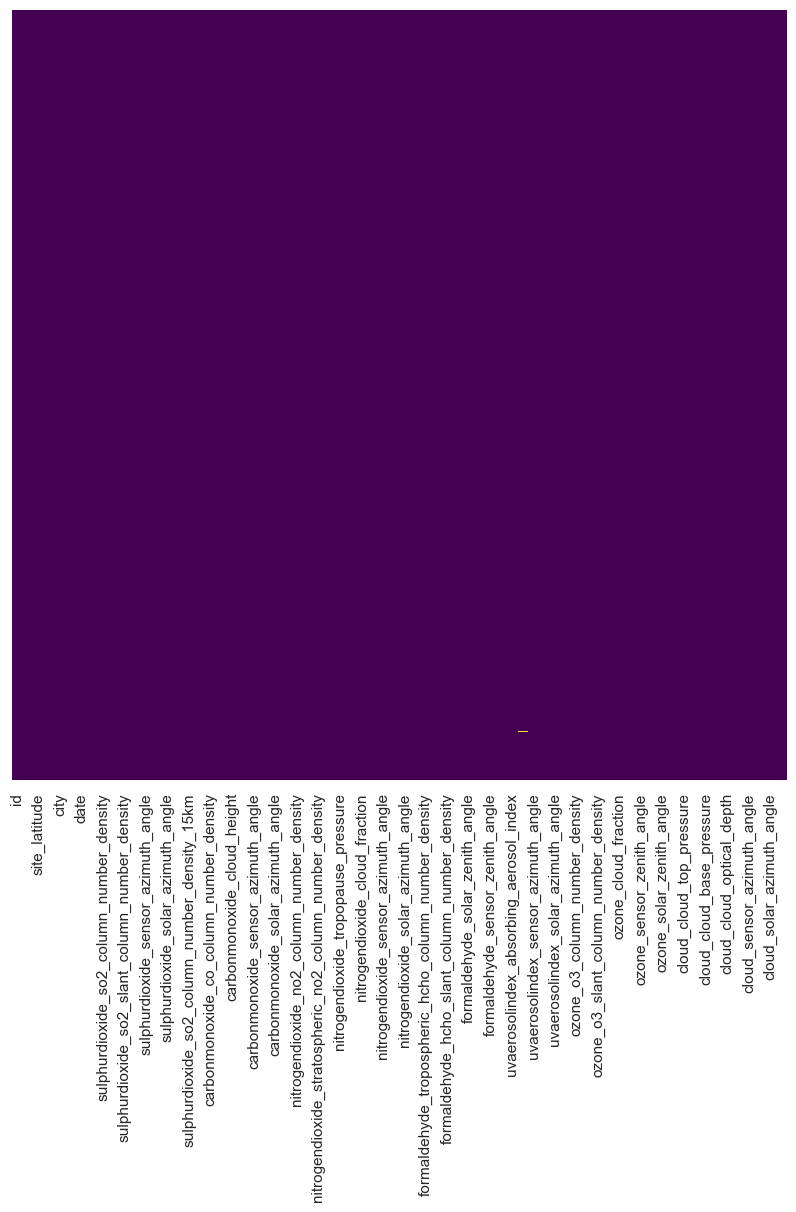

In [22]:
sns.heatmap(df_test.isnull(), yticklabels =False ,cbar =False , cmap ="viridis")

## Exploration of Data

<Figure size 200x1000 with 0 Axes>

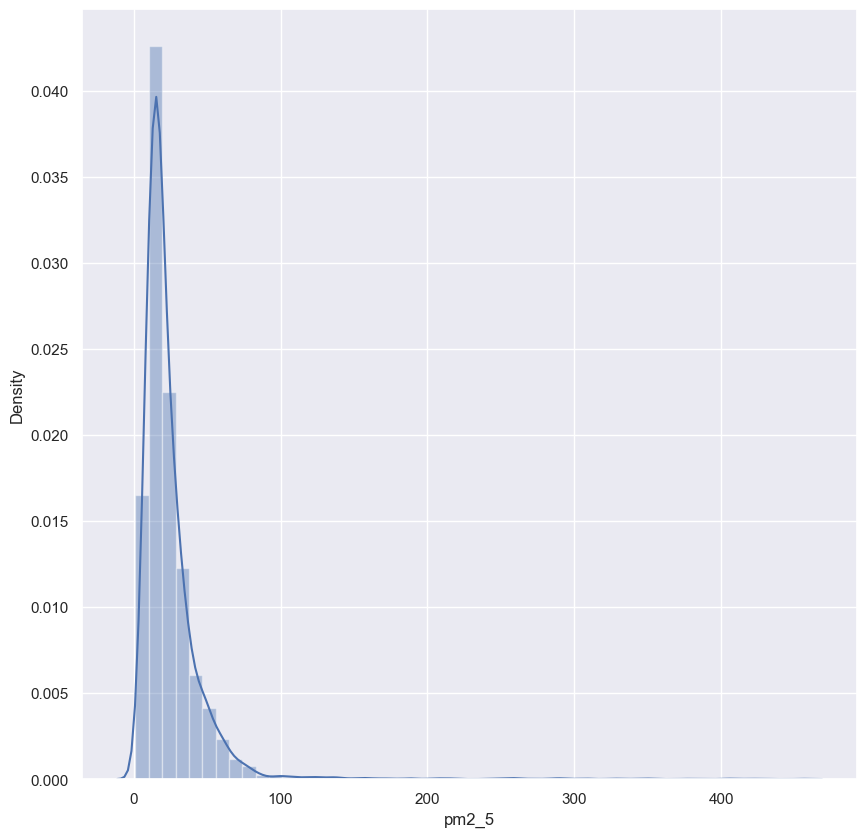

<Figure size 200x1000 with 0 Axes>

In [23]:
sns.distplot(df_train['pm2_5'])
plt.figure(figsize=(2,10))

In [24]:
df_train["pm2_5"].head().unique()

array([12.015     , 42.2672    , 39.45074074, 10.5376    , 19.43173077])

<Axes: xlabel='pm2_5', ylabel='date'>

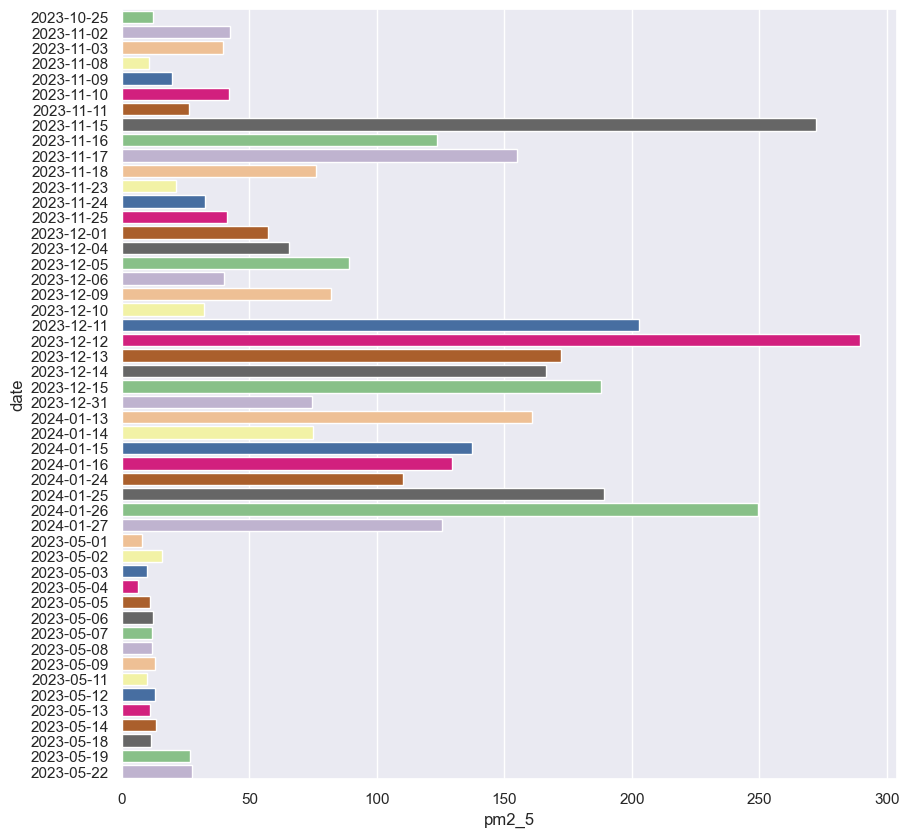

In [25]:
# date vs pm2_5
#from the data below om the 12th of december 2023 pollution detected was very high
# this is because it was close to the end of the year and preparation for the new year
 
sns.barplot(y="date", x="pm2_5",data= df_train[:50] , orient = "horizontal",palette ="Accent" )

<Axes: xlabel='pm2_5', ylabel='hour'>

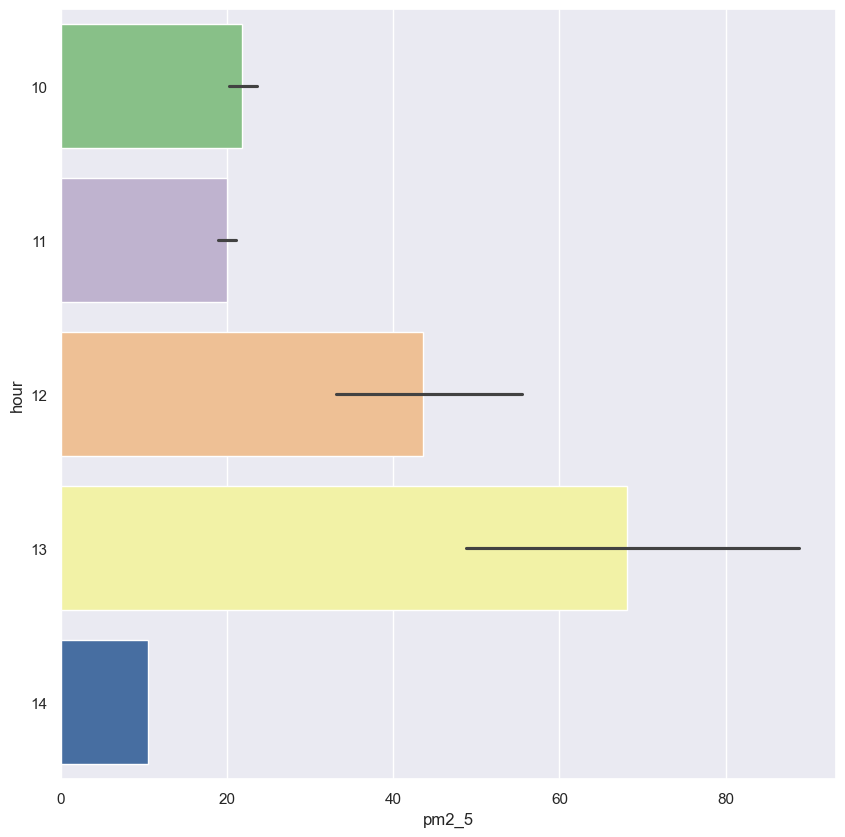

In [26]:
# hour vs pm2_5
# rate at which the pollution lasted the most was 13 hours
sns.barplot(y="hour", x="pm2_5",data= df_train[:1000] , orient = "horizontal",palette ="Accent" )

In [27]:
df_train["month"].unique()

array([10., 11., 12.,  1.,  5.,  6.,  7.,  8.,  9.,  2.,  3.,  4.])

<Figure size 1000x1000 with 0 Axes>

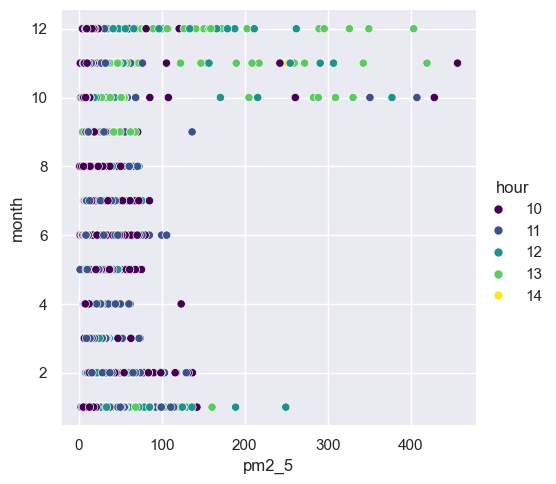

<Figure size 1000x1000 with 0 Axes>

In [28]:
# pm2_5 vs hour vs month
# towards the end of the month from october to december we see that pollution increased rapidly
# the most frequent hours which a pollution last is 10, 11, and 12 
#but towards the end of the year some pollutions last as long as 13 hours month and this can be due to the type of gas released
# January was also one month that had nlarge pollution this could be because , it wasthe entrance of a new year
    
sns.relplot(x="pm2_5", y="month", hue="hour",data=df_train, palette ="viridis",)
plt.figure(figsize=(10,10))

<Figure size 200x1000 with 0 Axes>

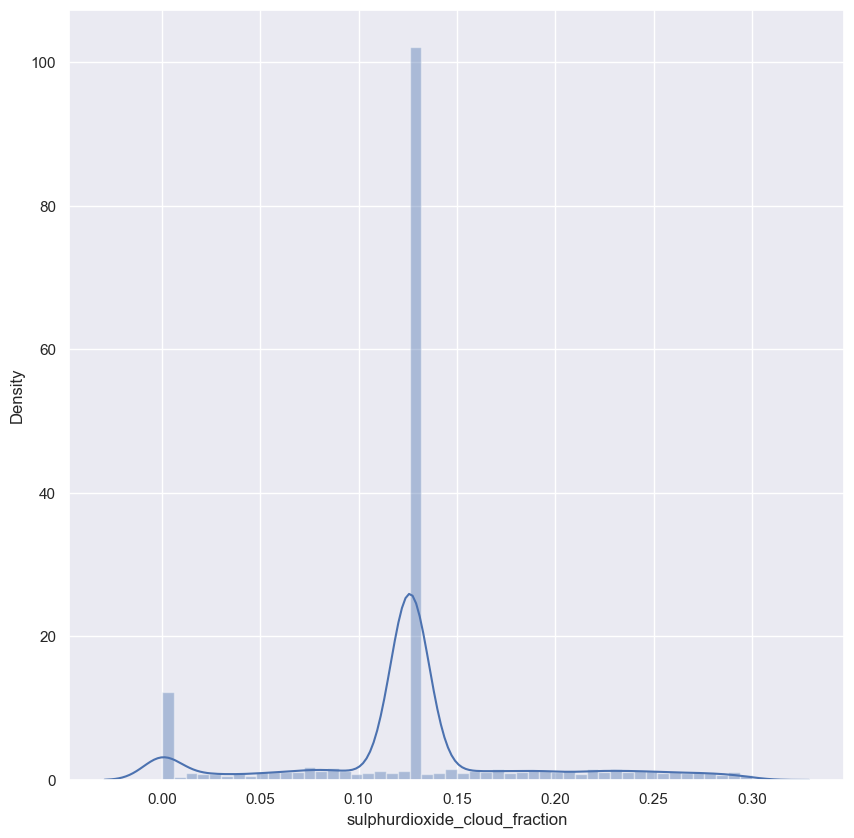

<Figure size 200x1000 with 0 Axes>

In [29]:
# sulphurdioxide_cloud_fraction is normally distributed and it as some outliers within the 0.10 and 0.15 fraction of the cloud
sns.distplot(df_train["sulphurdioxide_cloud_fraction"])
plt.figure(figsize=(2,10))

<Axes: xlabel='pm2_5', ylabel='country'>

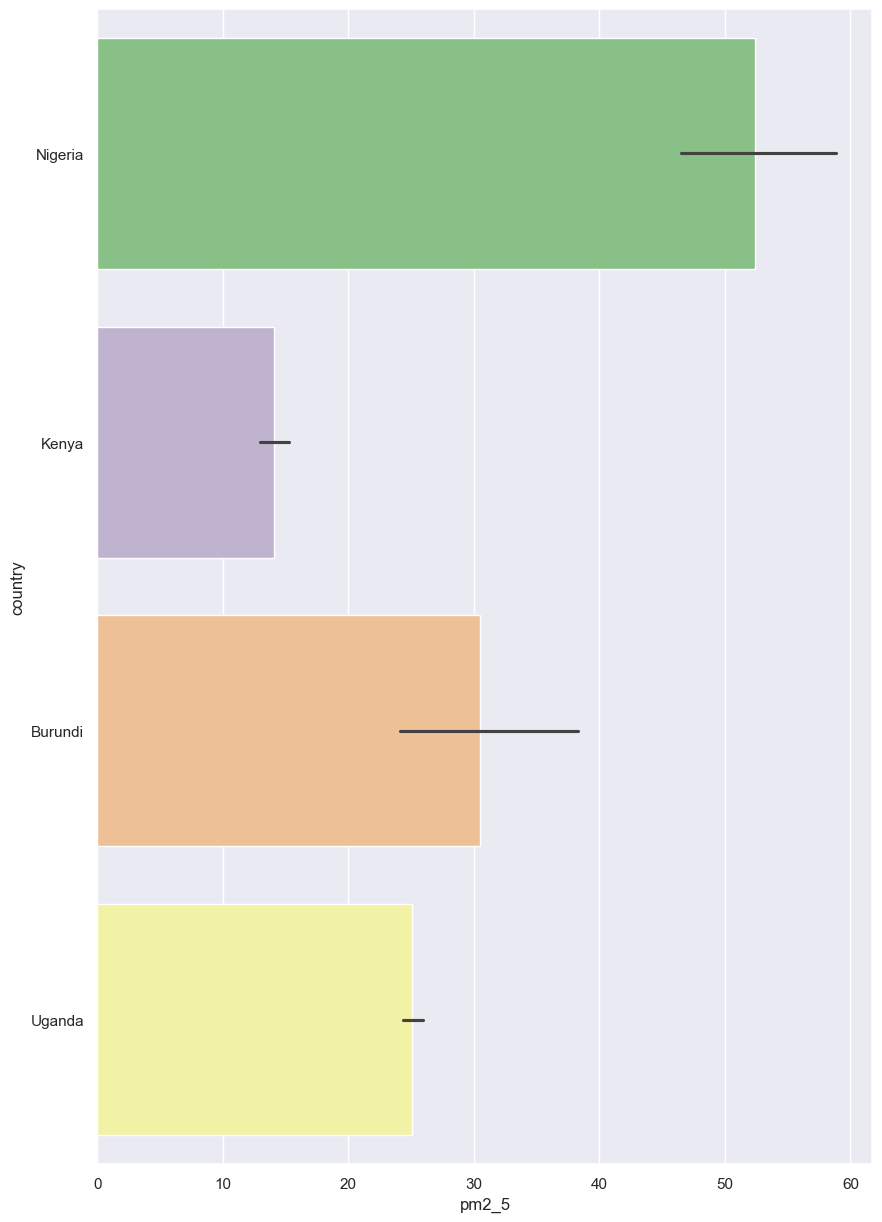

In [30]:
# pm2_5 vs country
# from the image below we see that nigeria as the most air polution and this could be because of the large industries within the country
plt.figure(figsize=(10,15))
sns.barplot(y="country", x="pm2_5",data= df_train[:2000] , orient = "horizontal",palette ="Accent" )

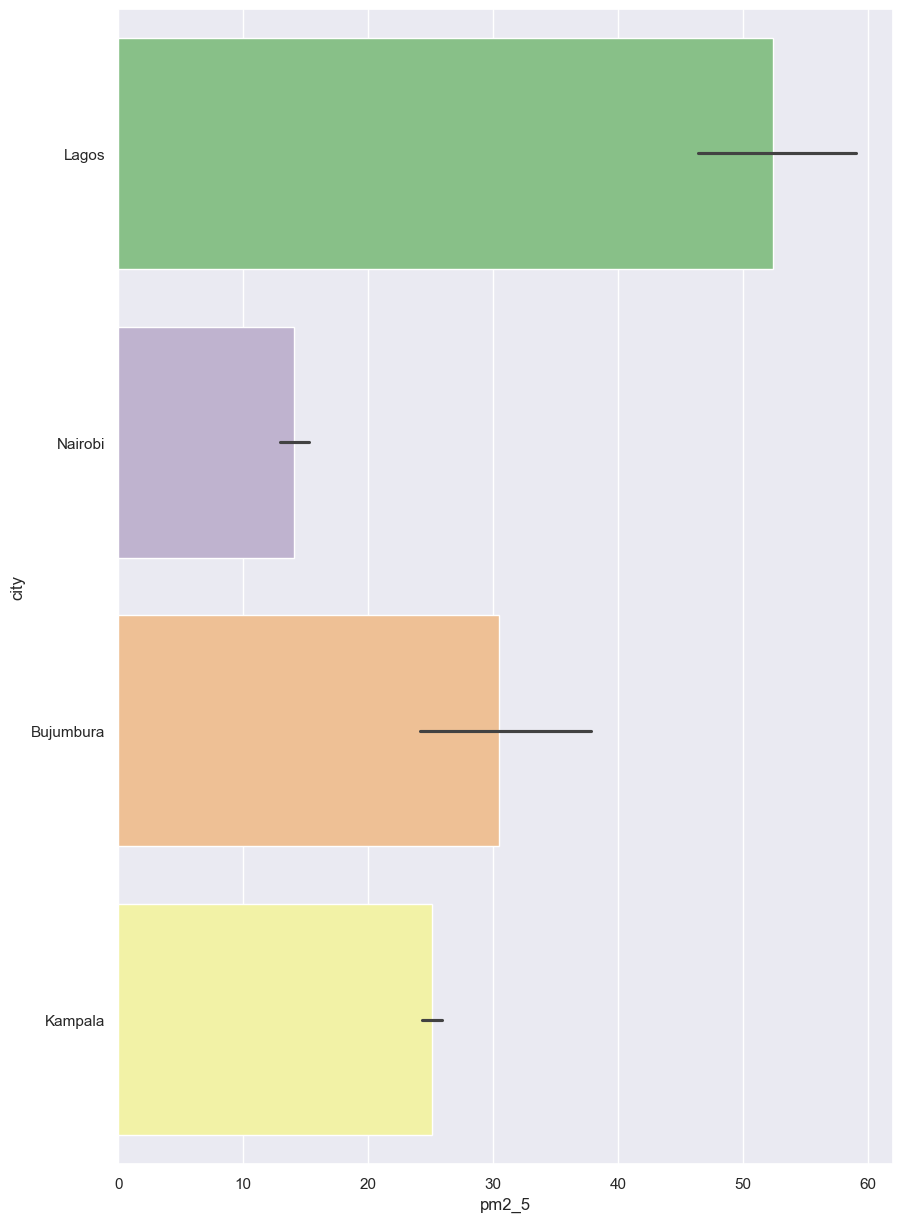

In [31]:
# city vs pm2_5
# lagos is the polluted among the 4 cities  
#  this is due to the within the city mismanagement waste product 
# and the large number of factories and road transport within the city
plt.figure(figsize=(10,15))
sns.barplot(y="city", x="pm2_5",data= df_train[:2000] , orient = "horizontal",palette ="Accent" )
plt.show()

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8071 entries, 0 to 8070
Data columns (total 73 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        8071 non-null   object 
 1   site_id                                                   8071 non-null   object 
 2   site_latitude                                             8071 non-null   float64
 3   site_longitude                                            8071 non-null   float64
 4   city                                                      8071 non-null   object 
 5   country                                                   8071 non-null   object 
 6   date                                                      8071 non-null   object 
 7   hour                                                      8071 non-null   int64  
 8   sulphurdioxide_so2

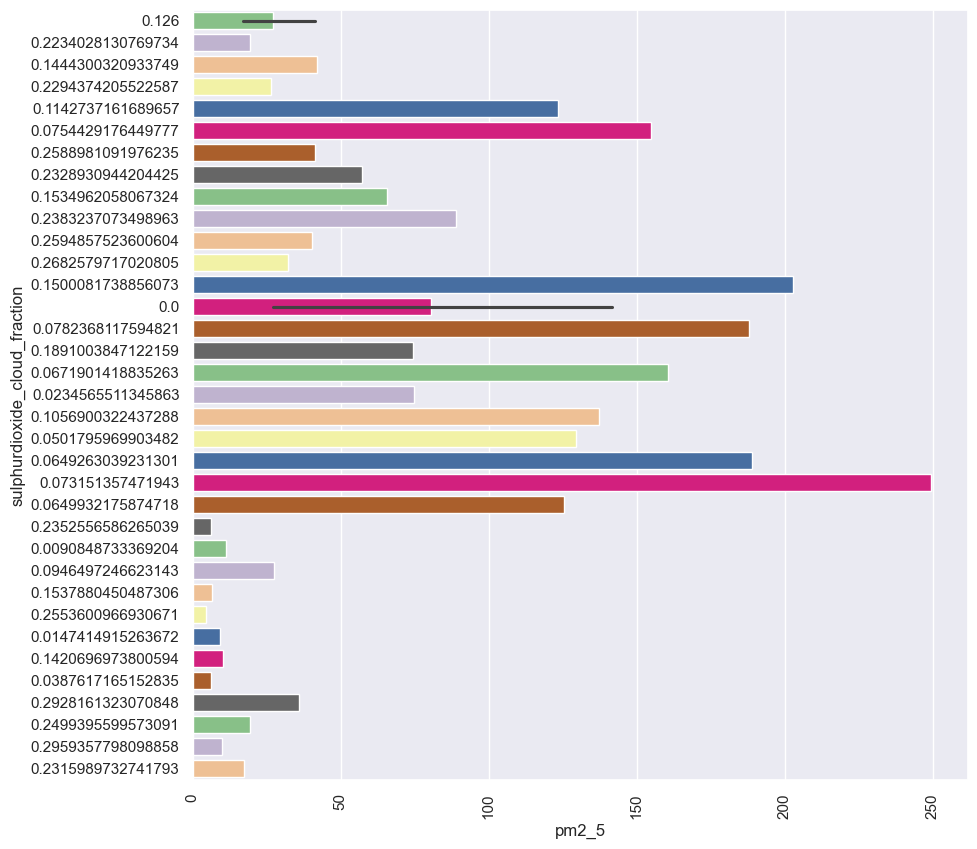

In [33]:
#  at 0.073 of sulphurdioxide_cloud_fraction pollution of sulphurdioxide was high
sns.barplot(y="sulphurdioxide_cloud_fraction", x="pm2_5",data= df_train[:100] , orient = "horizontal",palette ="Accent" )
# Tilt x-axis tick labels
plt.xticks(rotation=90)
plt.show()


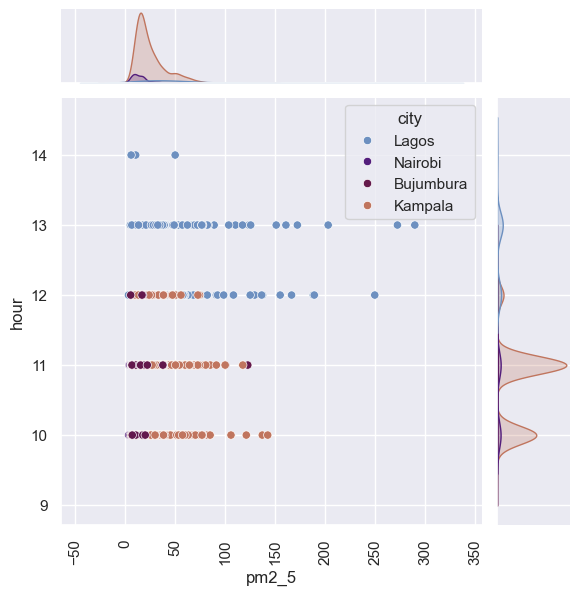

In [34]:
#hour vs pm2_5 vs city
# lagos is the ost pollulated city reach up to 12 to 13 hours of pollution , this is due to the large factures and indutiries in the city 
# Nairobi  s the pollulated city this is becuase there is not alot of industries like that of lagos and the population is not up to lagos 

sns.jointplot(y="hour", x="pm2_5",hue ="city", data= df_train[:2000], palette ='twilight')

  # Tilt x-axis tick labels
plt.xticks(rotation=90)
plt.show()


In [35]:
 for column in df_train.columns:
    if 'sulphurdioxide' in column:
        print(column)
 

sulphurdioxide_so2_column_number_density
sulphurdioxide_so2_column_number_density_amf
sulphurdioxide_so2_slant_column_number_density
sulphurdioxide_cloud_fraction
sulphurdioxide_sensor_azimuth_angle
sulphurdioxide_sensor_zenith_angle
sulphurdioxide_solar_azimuth_angle
sulphurdioxide_solar_zenith_angle
sulphurdioxide_so2_column_number_density_15km


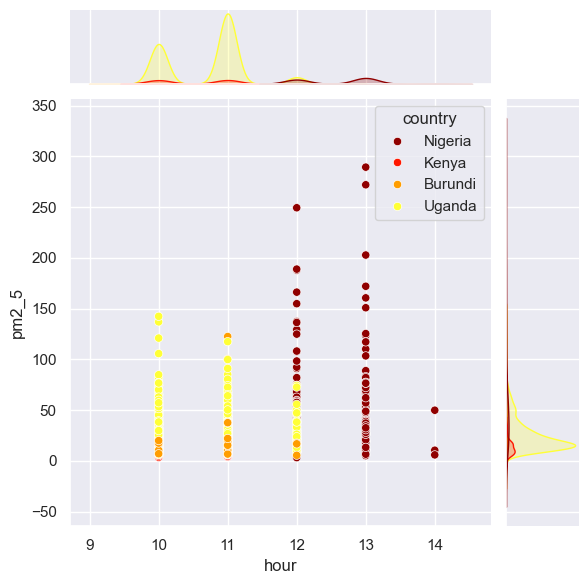

In [36]:
# Nigeria was the most pollulated country and Burundi had the least pollution
# the country with long lasting hour of pollution was Nigeria ranging from 12 hours to 14 hours
# kenya as the least pollution of all countries 
# some reason colud the kind of factories avaliable in the country and how developed it is.

sns.jointplot(hue="country", y="pm2_5",x="hour", data= df_train[:2000], palette ='hot')


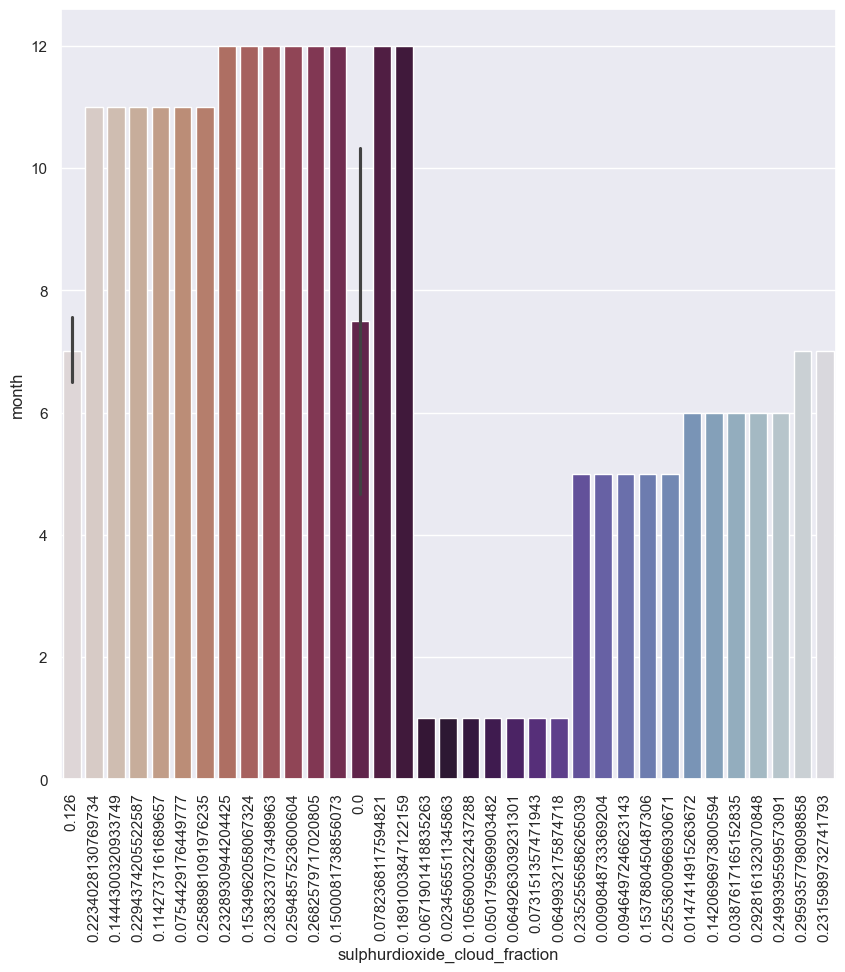

In [37]:
# month vs sulphurdioxide_cloud_fraction
# The 12th month which is decmber hard the most of sulphurdioxide_cloud_fraction in the atmosphere and it is due to indutries combustion 
# and waste product from moving vechicle due to large movement of vechles

sns.barplot(x="sulphurdioxide_cloud_fraction", y="month", data= df_train[:100], palette ='twilight_r')
 # Tilt x-axis tick labels
plt.xticks(rotation=90)
plt.show()


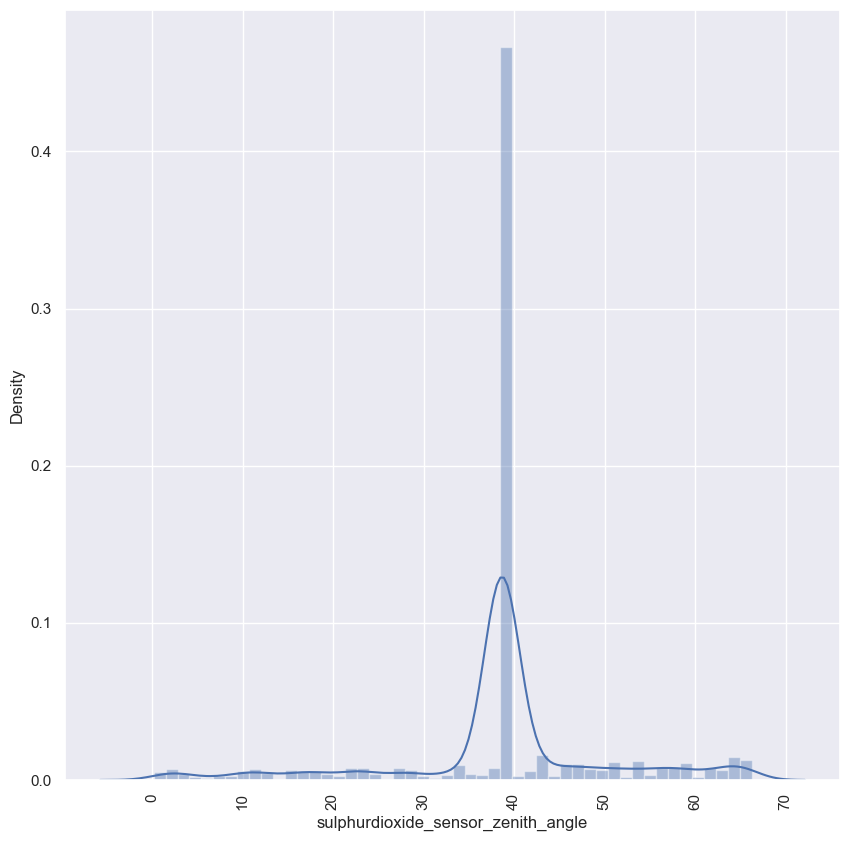

In [38]:
# from the displot image of sulphurdioxide_sensor_zenith_angle most angle that frequntly occurred is at 40 degree
sns.distplot(df_train["sulphurdioxide_sensor_zenith_angle"]),
 # Tilt x-axis tick labels
plt.xticks(rotation=90)
plt.show()


<Axes: xlabel='sulphurdioxide_sensor_azimuth_angle', ylabel='Density'>

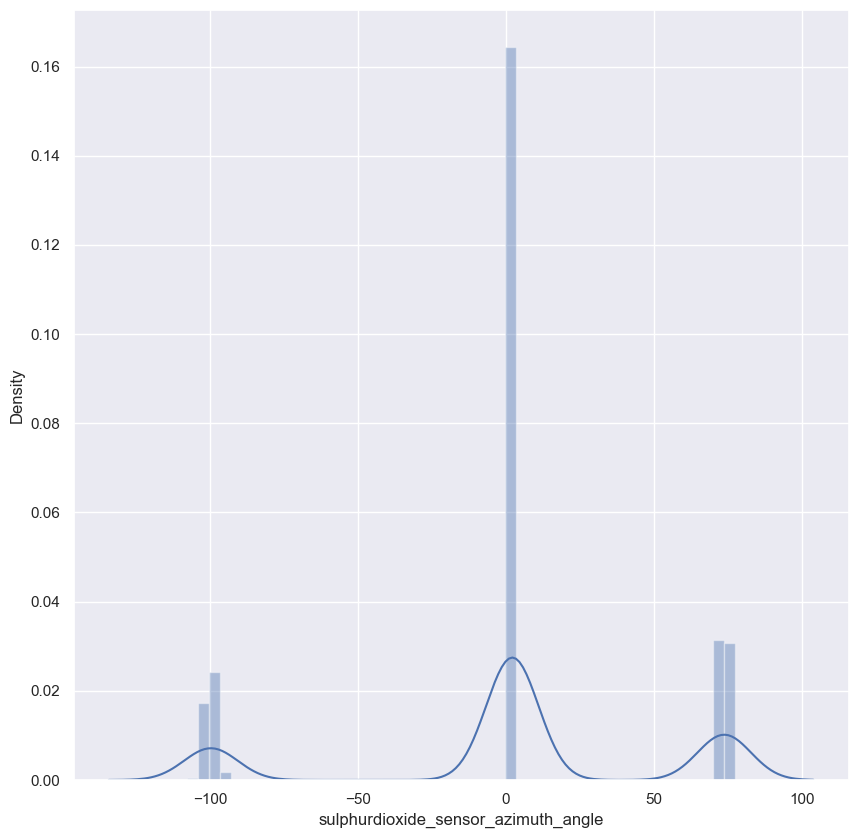

In [39]:
# sulphurdioxide_sensor_azimuth_angle is normally distributed 
# at 60 to 70 degree the sulphurdioxide was high
sns.distplot(df_train["sulphurdioxide_sensor_azimuth_angle"])

<Axes: xlabel='carbonmonoxide_h2o_column_number_density', ylabel='Density'>

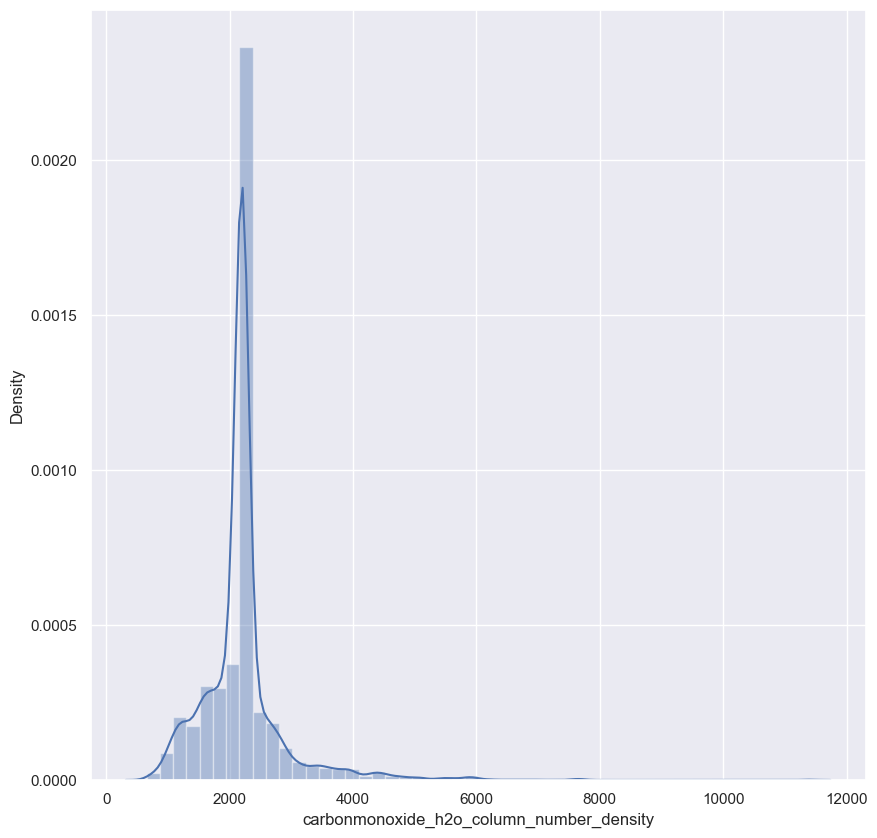

In [40]:
# the column number density for the carbonmonoxide of h20 range high at 2000
sns.distplot(df_train["carbonmonoxide_h2o_column_number_density"])

In [41]:
for column in df_train.columns:
    if 'carbonmonoxide' in column:
        print(column)
 

carbonmonoxide_co_column_number_density
carbonmonoxide_h2o_column_number_density
carbonmonoxide_cloud_height
carbonmonoxide_sensor_altitude
carbonmonoxide_sensor_azimuth_angle
carbonmonoxide_sensor_zenith_angle
carbonmonoxide_solar_azimuth_angle
carbonmonoxide_solar_zenith_angle


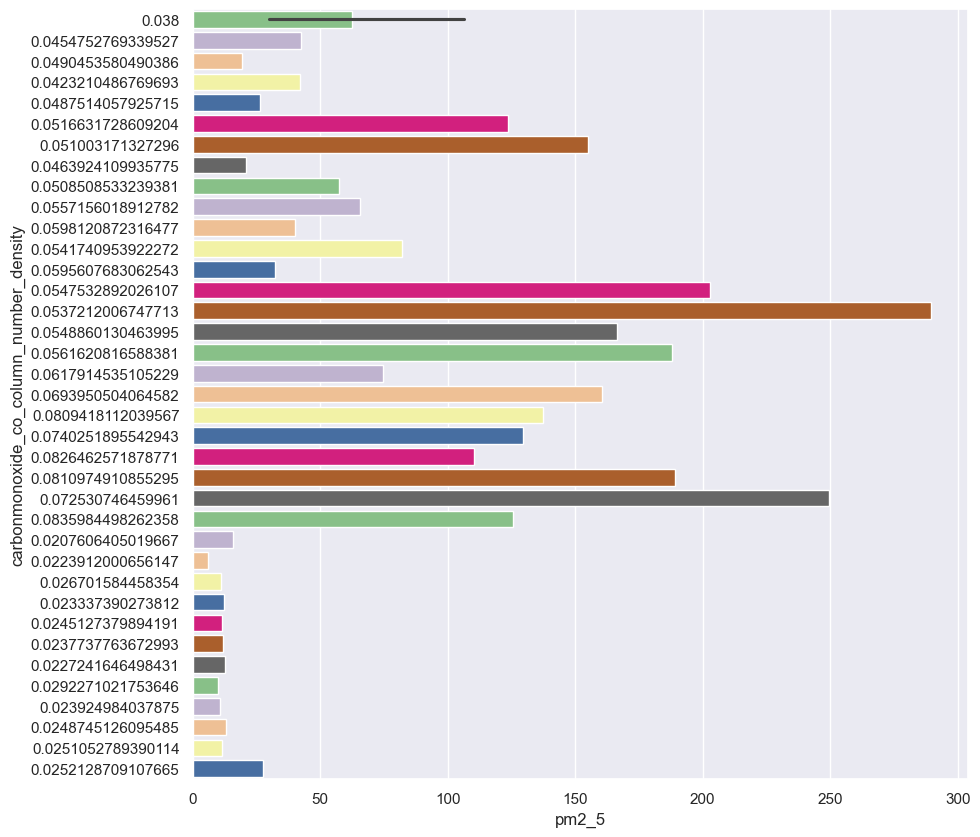

In [42]:
# carbonmonoxide_co_column_number_density vs pm2_5
# at 0.053 of carbonmonoxide_co_column_number_density, carbonmonoxide was seen to be the highest 
sns.barplot(y="carbonmonoxide_co_column_number_density", x="pm2_5",data= df_train[:50] , orient = "horizontal",palette ="Accent" )
plt.show()

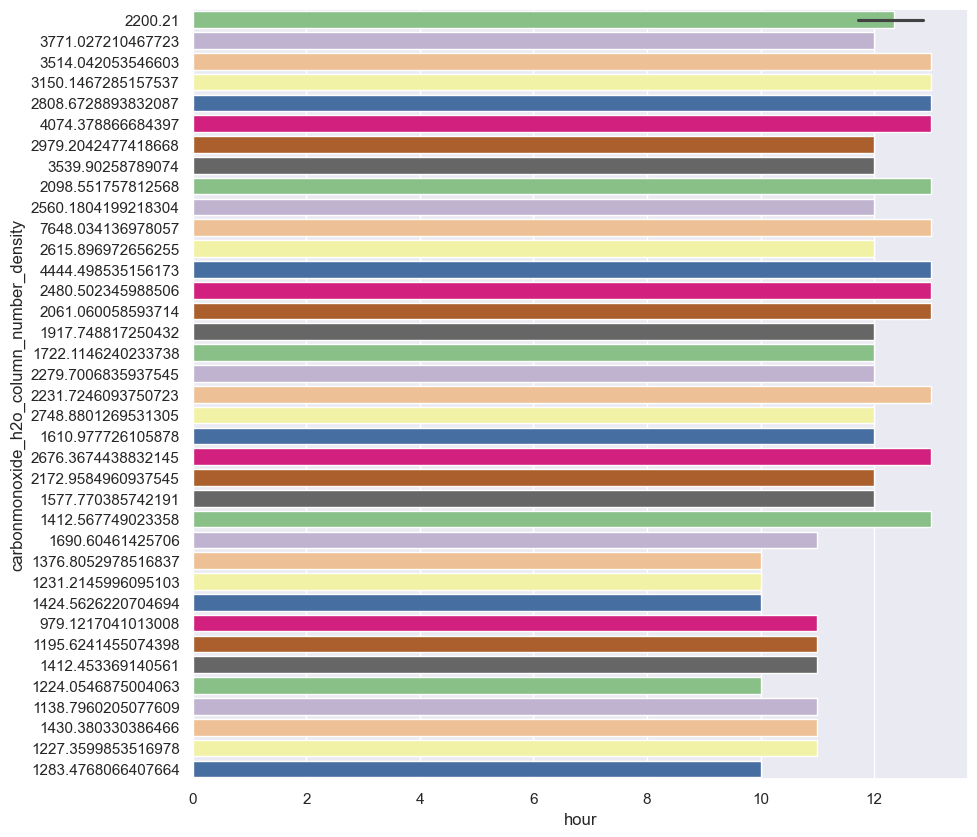

In [43]:
# carbonmonoxide_h2o_column_number_density vs hour
sns.barplot(y="carbonmonoxide_h2o_column_number_density", x="hour",data= df_train[:50] , orient = "horizontal",palette ="Accent" )
plt.show()

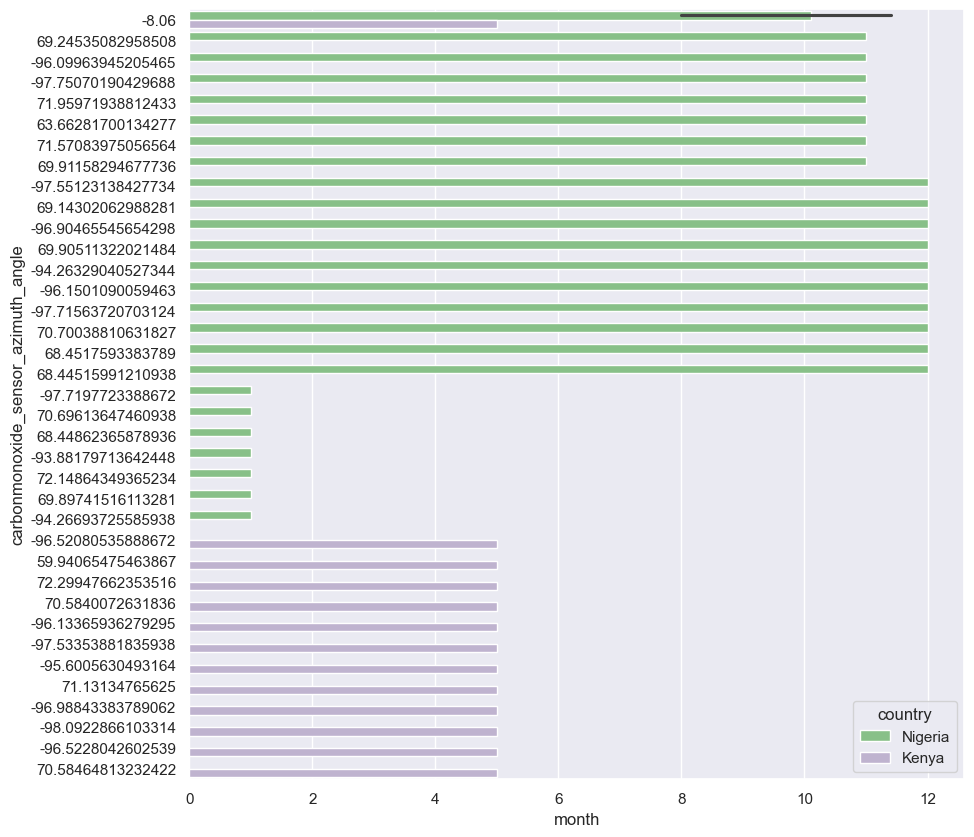

In [44]:
# carbonmonoxide_sensor_azimuth_angle vs month vs country
#  the 12th month which is december nigeria had the most pollution
#  the 5th month which is may , kenya had more pollution

sns.barplot(y="carbonmonoxide_sensor_azimuth_angle", x="month",hue="country",data= df_train[:50] , orient = "horizontal",palette ="Accent" )
plt.show()

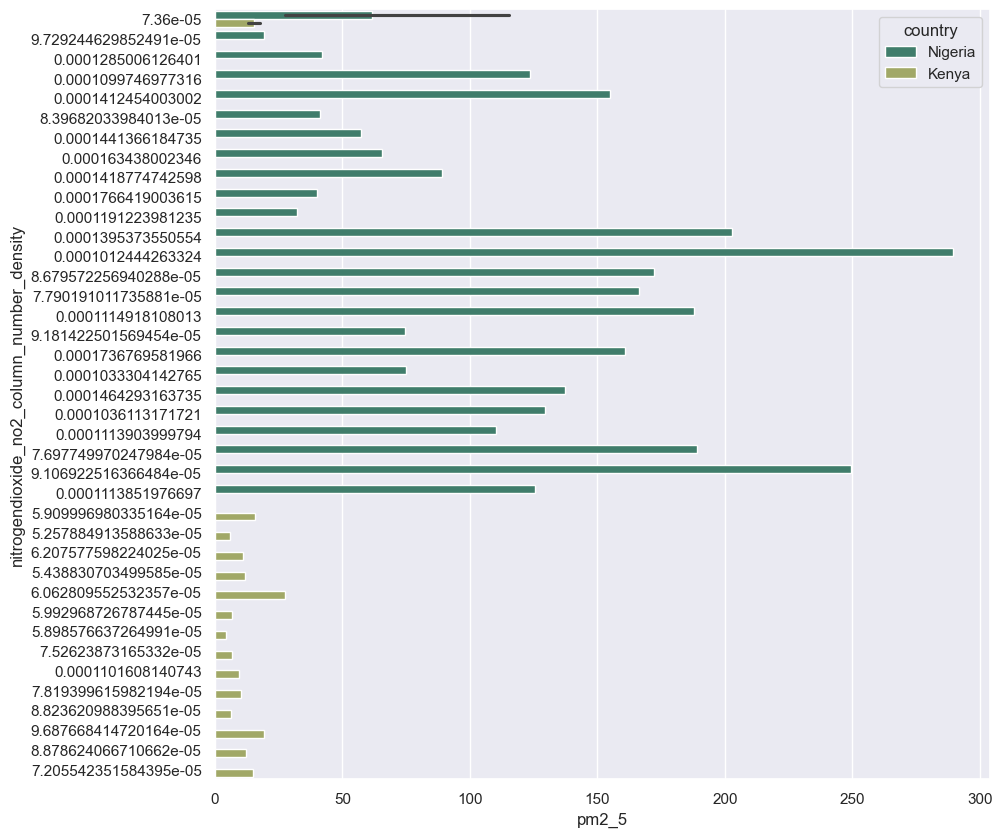

In [45]:
#  nitrogendioxide_no2_column_number_density vs pm2_5 vs country
#  nigeria had the most pollution
#  kenya as least pollution

sns.barplot(y="nitrogendioxide_no2_column_number_density", x="pm2_5",hue="country",data= df_train[:90] , orient = "horizontal",palette ="gist_earth" )
plt.show()

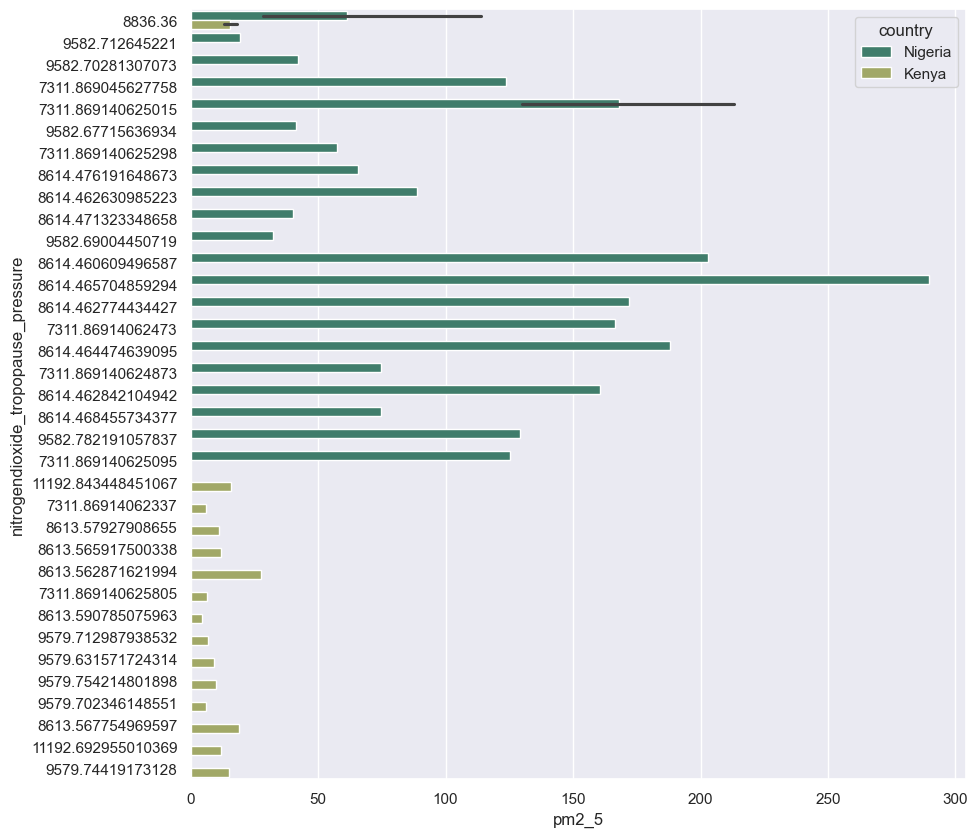

In [46]:
#  nitrogendioxide_tropopause_pressure vs pm2_5 vs country
#   nigeria had the most pollution at the tropopause
#   kenya had more pollution least pollution at the tropopause

sns.barplot(y="nitrogendioxide_tropopause_pressure", x="pm2_5",hue="country",data= df_train[:90] , orient = "horizontal",palette ="gist_earth" )
plt.show()

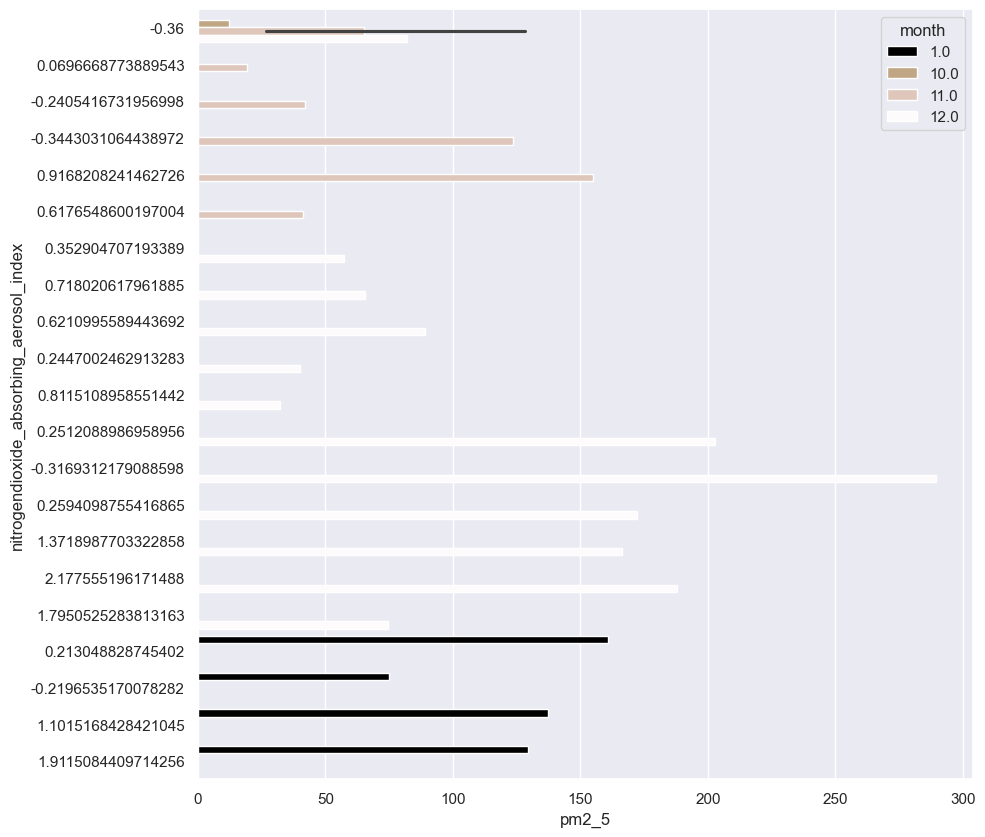

In [47]:
#  nitrogendioxide_absorbing_aerosol_index vs pm2_5 vs month
#   nigeria had the most pollution at the tropopause
#   kenya had more pollution least pollution at the tropopause
 
sns.barplot(y="nitrogendioxide_absorbing_aerosol_index", x="pm2_5",hue="month",data= df_train[:30] , orient = "horizontal",palette ="gist_earth" )
plt.show()

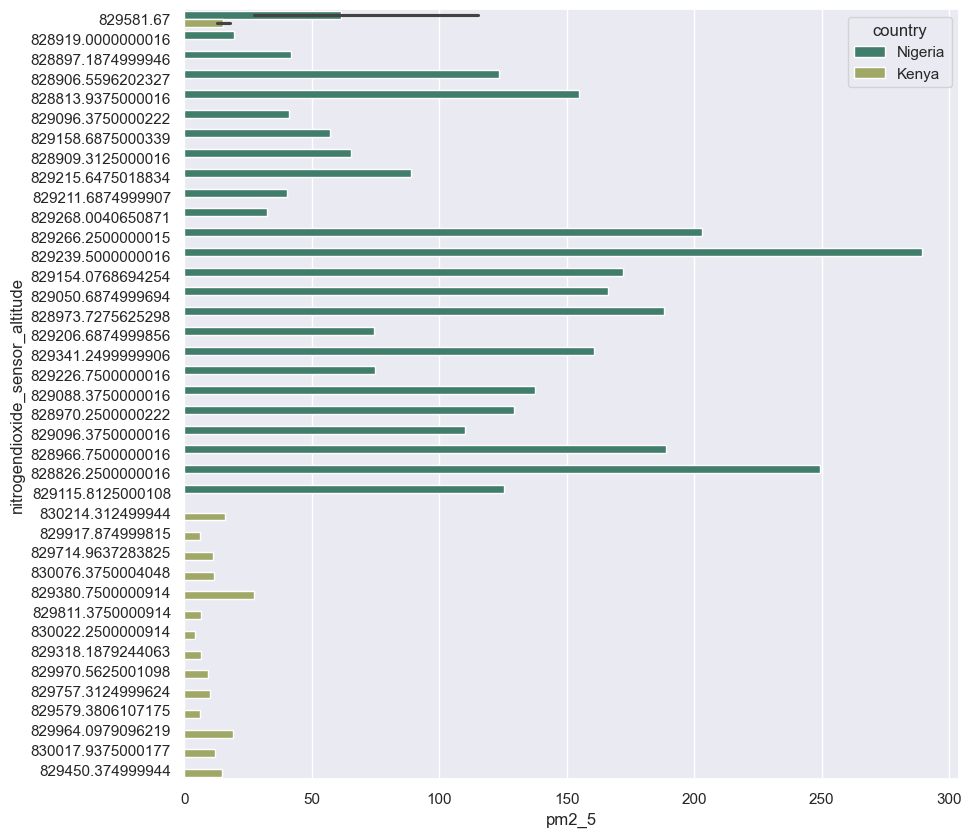

In [48]:
# nitrogendioxide_sensor_altitude, pm2_5,country
# the detect mor of nitrogendioxide in Nigeria
# the higest altitude is at 829239.500

sns.barplot(y="nitrogendioxide_sensor_altitude", x="pm2_5",hue="country",data= df_train[:90] , orient = "horizontal",palette ="gist_earth" )
plt.show()

In [49]:
for column in df_train.columns:
    if 'nitrogendioxide' in column:
        print(column)
 

nitrogendioxide_no2_column_number_density
nitrogendioxide_tropospheric_no2_column_number_density
nitrogendioxide_stratospheric_no2_column_number_density
nitrogendioxide_no2_slant_column_number_density
nitrogendioxide_tropopause_pressure
nitrogendioxide_absorbing_aerosol_index
nitrogendioxide_cloud_fraction
nitrogendioxide_sensor_altitude
nitrogendioxide_sensor_azimuth_angle
nitrogendioxide_sensor_zenith_angle
nitrogendioxide_solar_azimuth_angle
nitrogendioxide_solar_zenith_angle


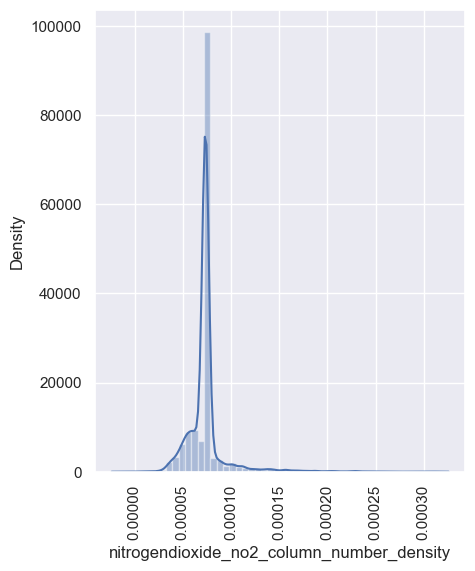

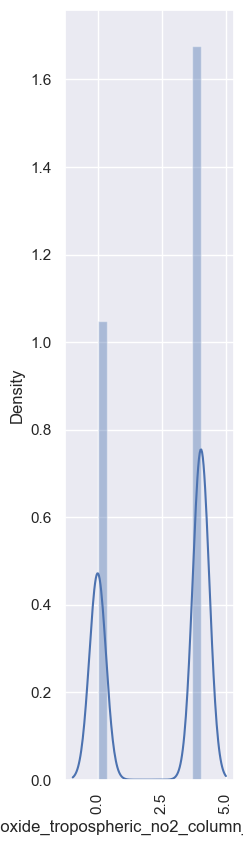

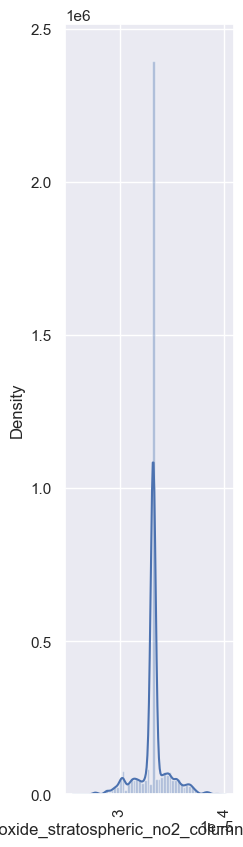

In [50]:
plt.figure(figsize=(22, 6))

plt.subplot(141)
sns.distplot(df_train["nitrogendioxide_no2_column_number_density"])
plt.xticks(rotation=90)
plt.show()

plt.subplot(142)
sns.distplot(df_train["nitrogendioxide_tropospheric_no2_column_number_density"])
plt.xticks(rotation=90)
plt.show()

plt.subplot(143)
sns.distplot(df_train["nitrogendioxide_stratospheric_no2_column_number_density"])
plt.xticks(rotation=90)
plt.show()


In [51]:
for column in df_test.columns:
    if 'formaldehyde' in column:
        print(column)


formaldehyde_tropospheric_hcho_column_number_density
formaldehyde_tropospheric_hcho_column_number_density_amf
formaldehyde_hcho_slant_column_number_density
formaldehyde_cloud_fraction
formaldehyde_solar_zenith_angle
formaldehyde_solar_azimuth_angle
formaldehyde_sensor_zenith_angle
formaldehyde_sensor_azimuth_angle


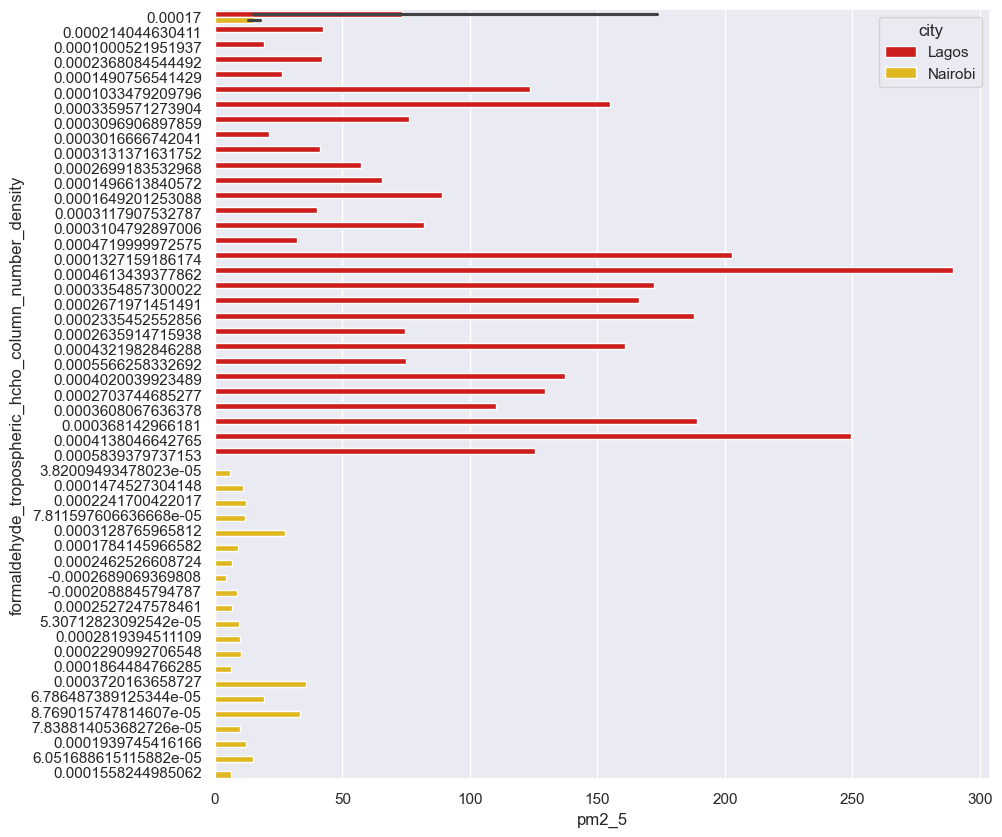

In [52]:
#  formaldehyde_tropospheric_hcho_column_number_density vs pm2_5 vs city
# formaldehyde more at Lagos tropospheric than that of Nairobi
# from the pm2_5the column number density of formaldehyde was at 0.000137
sns.barplot(y="formaldehyde_tropospheric_hcho_column_number_density", x="pm2_5",hue="city",data= df_train[:90] , orient = "horizontal",palette ="hot" )
plt.show()

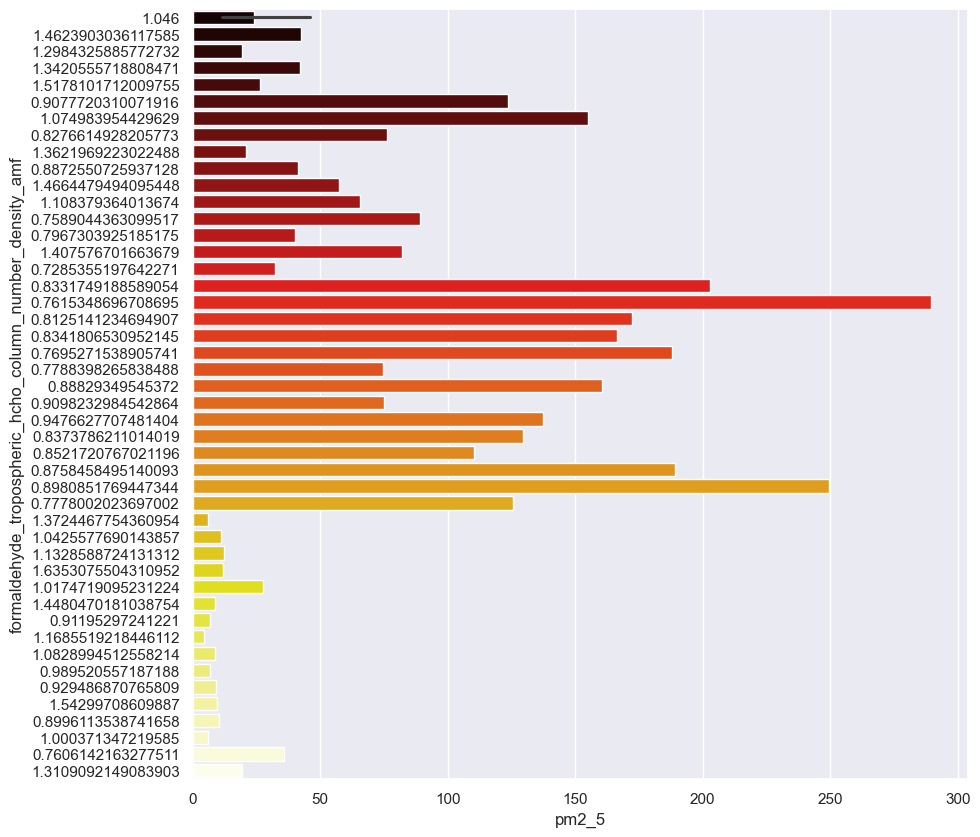

In [53]:
# formaldehyde_tropospheric_hcho_column_number_density_amf vs pm2_5
# formaldehyde was detected mostly at 0.76 at the troposphere 
sns.barplot(y="formaldehyde_tropospheric_hcho_column_number_density_amf", x="pm2_5",data= df_train[:70] , orient = "horizontal",palette ="hot" )
plt.show()

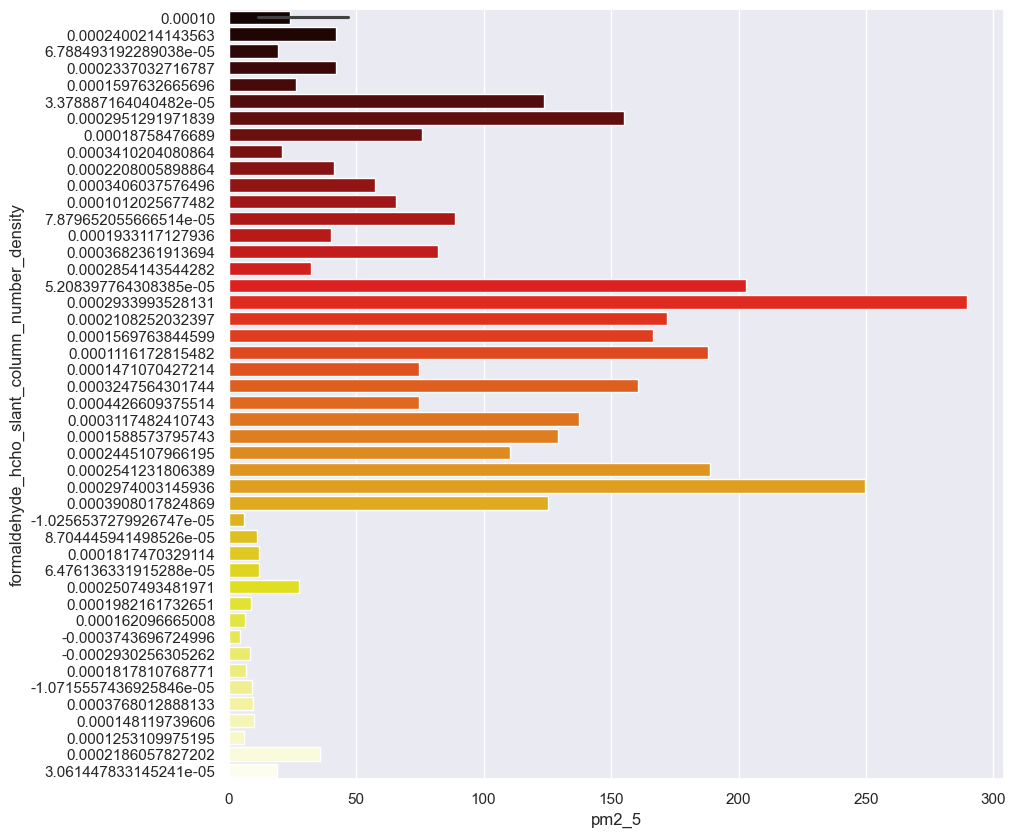

In [54]:

sns.barplot(y="formaldehyde_hcho_slant_column_number_density", x="pm2_5",data= df_train[:70] , orient = "horizontal",palette ="hot" )
plt.show()

<Axes: xlabel='pm2_5', ylabel='formaldehyde_cloud_fraction'>

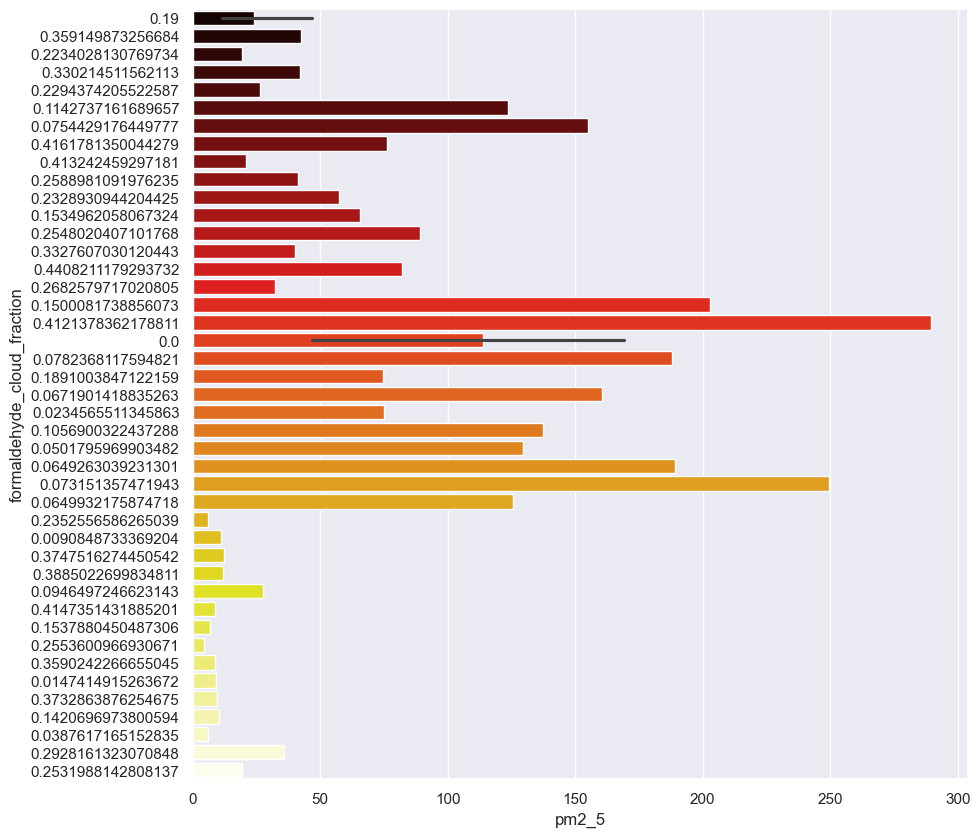

In [55]:
# formaldehyde_cloud_fraction vs pm2_5
# at cloud fraction 0.412 pm2_5 predict most of the formaldehyde
sns.barplot(y="formaldehyde_cloud_fraction", x="pm2_5",data= df_train[:70] , orient = "h",palette ="hot" )


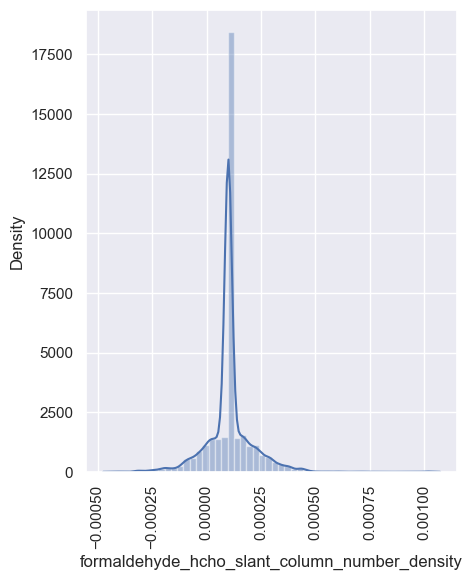

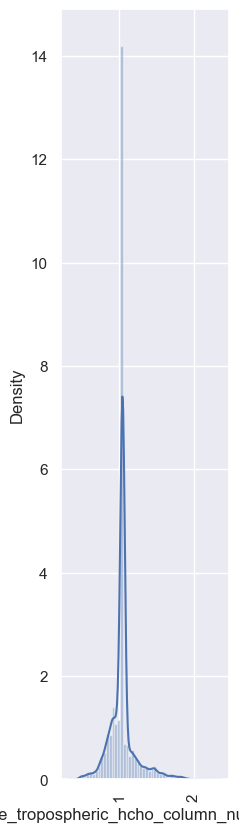

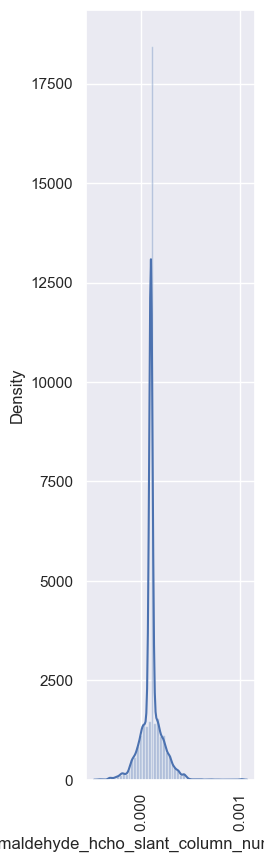

In [56]:
# distribution of formaldehyde_hcho_slant_column_number_density, 
#formaldehyde_tropospheric_hcho_column_number_density_amf, formaldehyde_hcho_slant_column_number_density
plt.figure(figsize=(22, 6))

plt.subplot(141)
sns.distplot(df_train["formaldehyde_hcho_slant_column_number_density"])
plt.xticks(rotation=90)
plt.show()

plt.subplot(142)
sns.distplot(df_train["formaldehyde_tropospheric_hcho_column_number_density_amf"])
plt.xticks(rotation=90)
plt.show()

plt.subplot(143)
sns.distplot(df_train["formaldehyde_hcho_slant_column_number_density"])
plt.xticks(rotation=90)
plt.show()


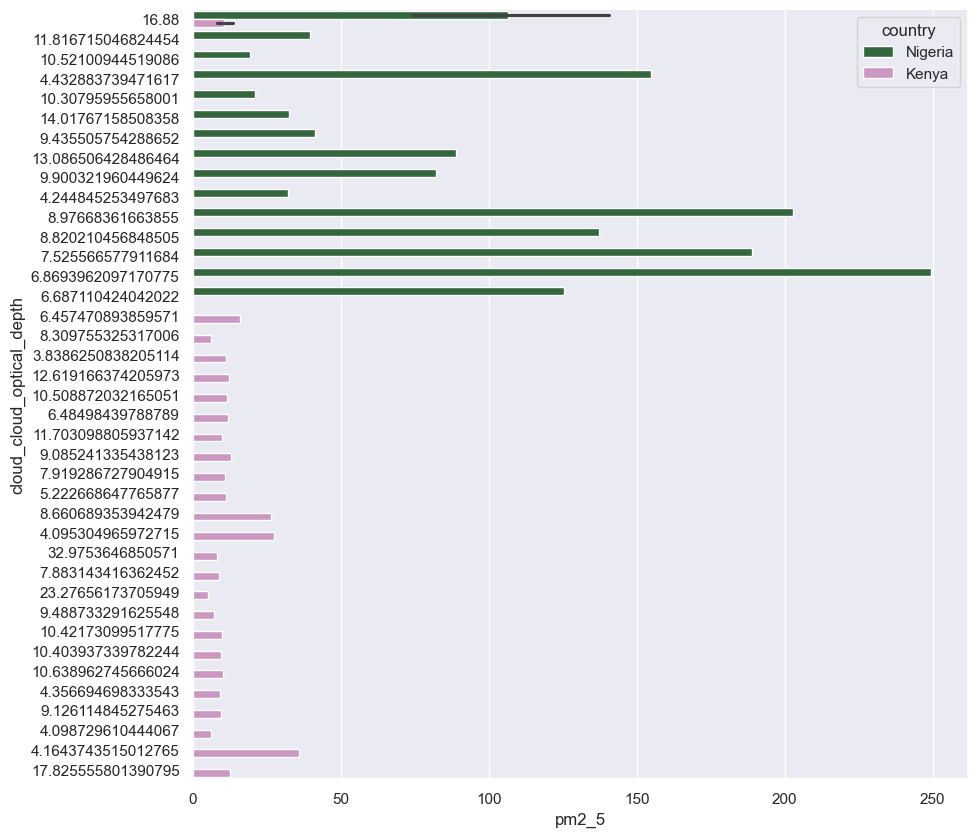

In [57]:
# cloud_cloud_optical_depth vs pm2_5 vs country
# Nigeria as less of the opitical cloud fraction that of kenya
# this is due to the less polliution in kenya
 
sns.barplot(y="cloud_cloud_optical_depth", x="pm2_5",hue = "country",data= df_train[:70] , orient = "horizontal",palette ="cubehelix" )
plt.show()

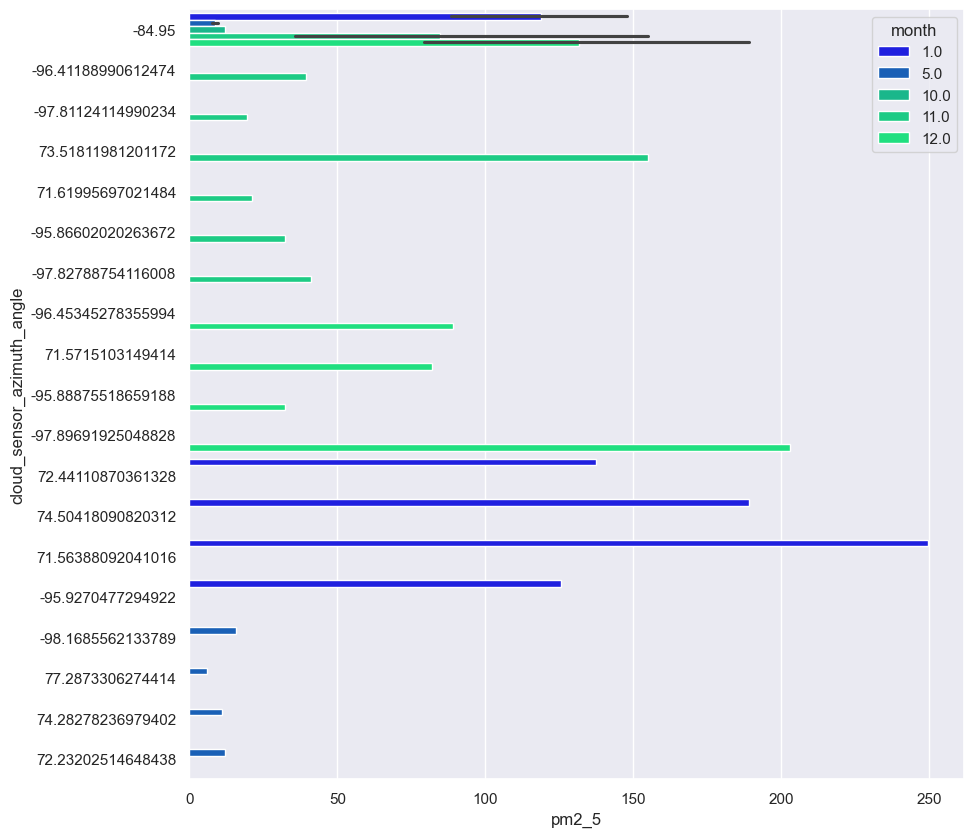

In [58]:
# cloud_sensor_azimuth_angle vs pm2_5 vs month
# the cloud sensor dectected most of the pm2_5 at the first month

sns.barplot(y="cloud_sensor_azimuth_angle", x="pm2_5",hue = "month",data= df_train[:40] , orient = "horizontal",palette ="winter" )
plt.show()

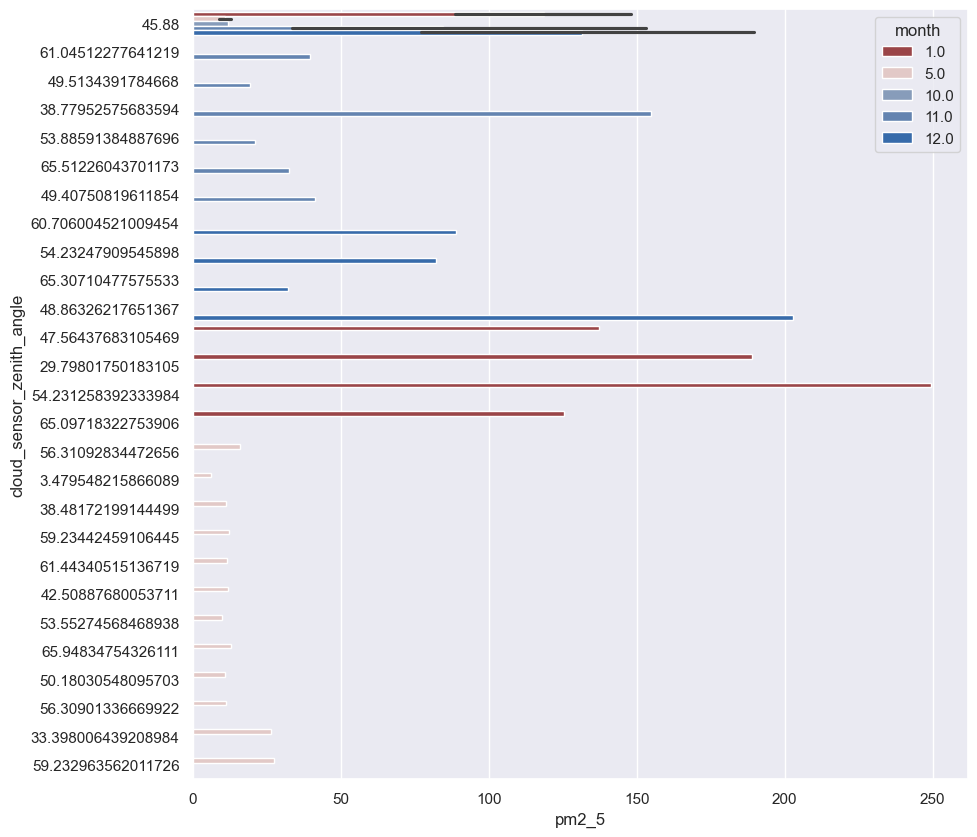

In [59]:
sns.barplot(y="cloud_sensor_zenith_angle", x="pm2_5",hue = "month",data= df_train[:50] , orient = "horizontal",palette ="vlag_r" )
plt.show()

## Exploration of Test Dataset

<Figure size 200x1000 with 0 Axes>

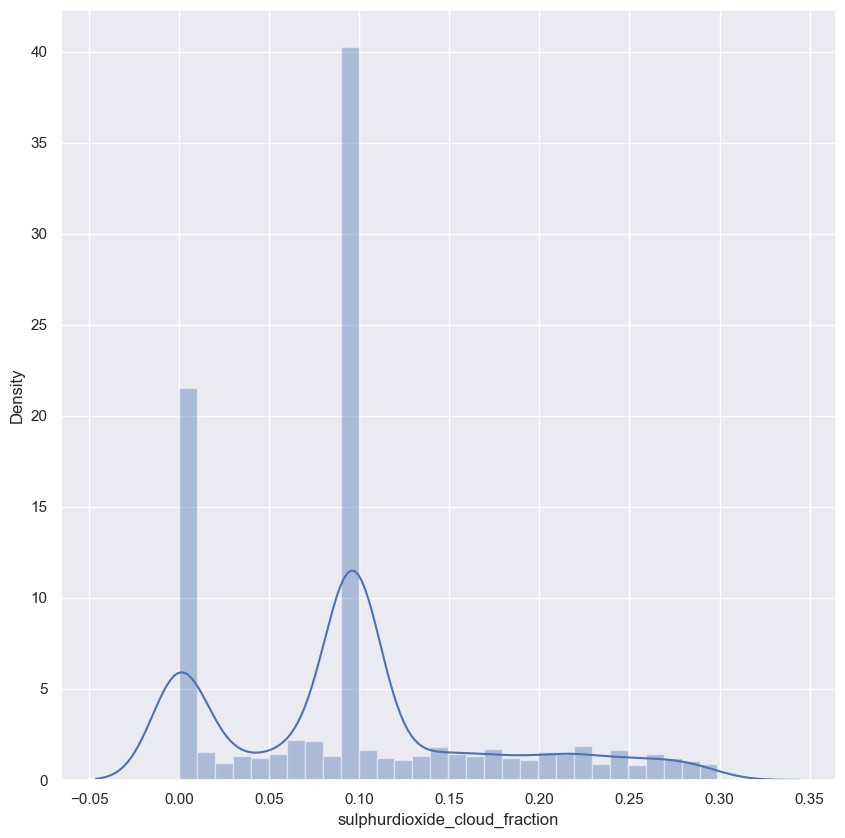

<Figure size 200x1000 with 0 Axes>

In [60]:
# date vs pm2_5
# from the data below om the 12th of december 2023 pollution detected was very high
# this is because it was close to the end of the year and preparation for the new year
 
sns.distplot(df_test["sulphurdioxide_cloud_fraction"])
plt.figure(figsize=(2,10))

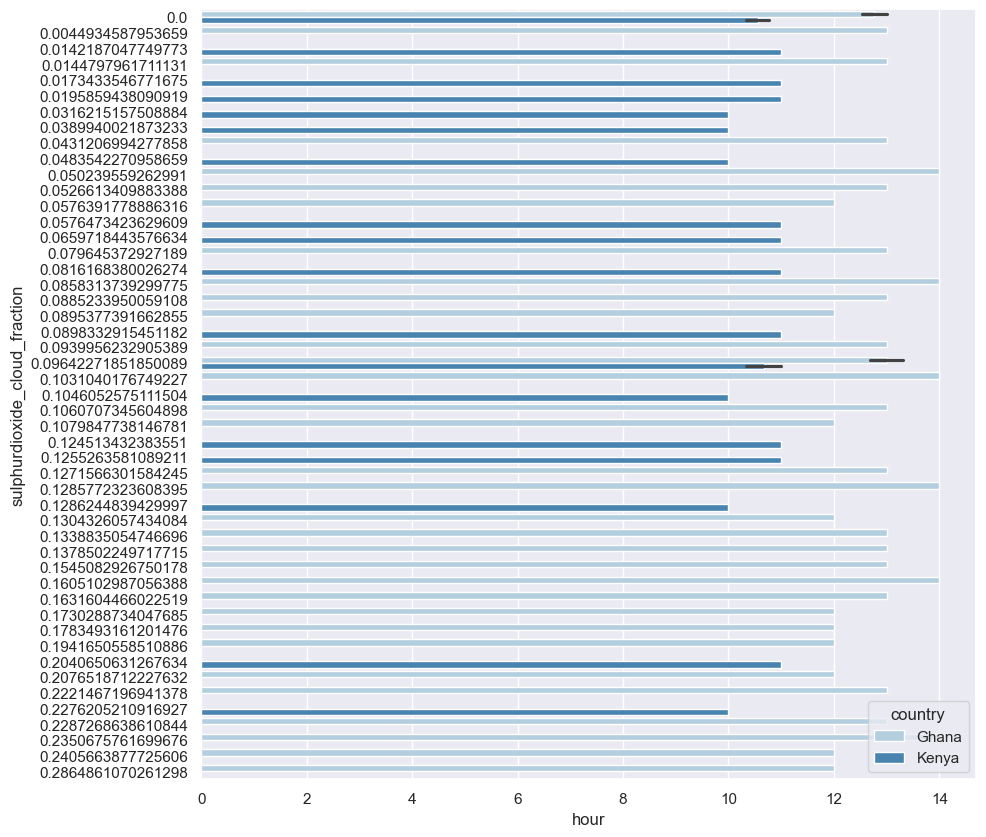

In [61]:
#  sulphurdioxide_cloud_fraction vs hour vs country
#  most sulphurdioxide was found more present in ghana than kenya
#  and occuppy most of the cloud fractions of ghana
#  it range the longest of hours of 12 to 14hrs
sns.barplot(y="sulphurdioxide_cloud_fraction", x="hour",hue = "country",data= df_test[:100] , orient = "horizontal",palette ="Blues" )
plt.show()

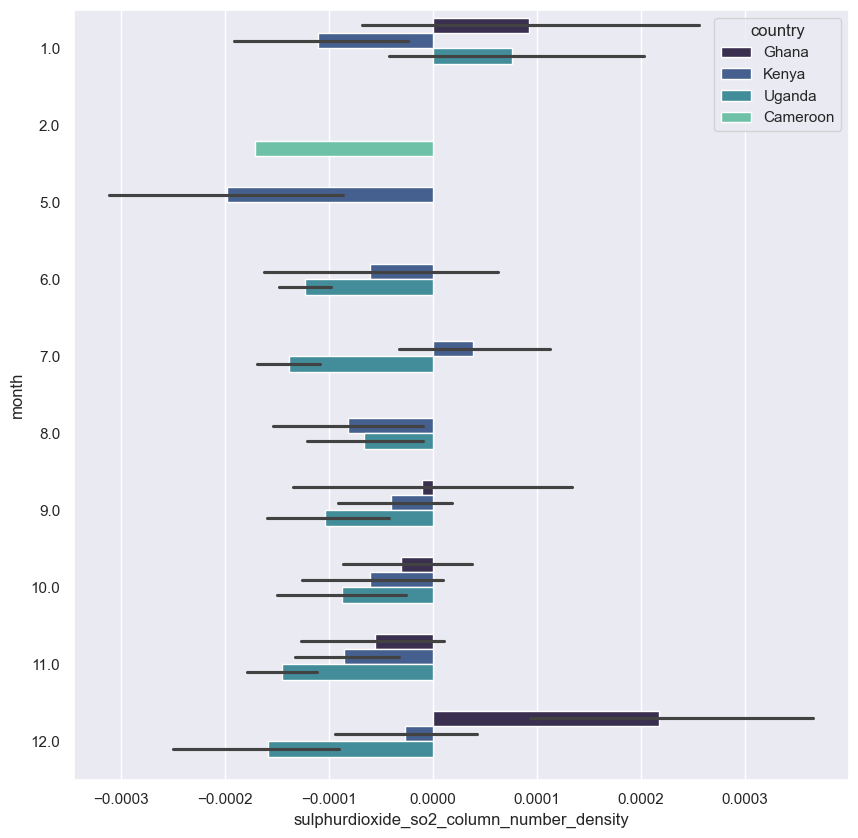

In [62]:
# month vs sulphurdioxide_so2_column_number_density vs country
# the positive value of the sulphurdioxide_so2_column_number_density dectect the amount of its presence 
# from the country below ghana show to have of sulphurdioxide in its atomsphere
# mostly in the first and last month but more in the last month
# uganda as most of the less amount of sulphurdioxide in its atomosphere than other country 
# cameroon show the country with less poillution of sulphurdioxide
sns.barplot(y="month", x="sulphurdioxide_so2_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="mako" )
plt.show()

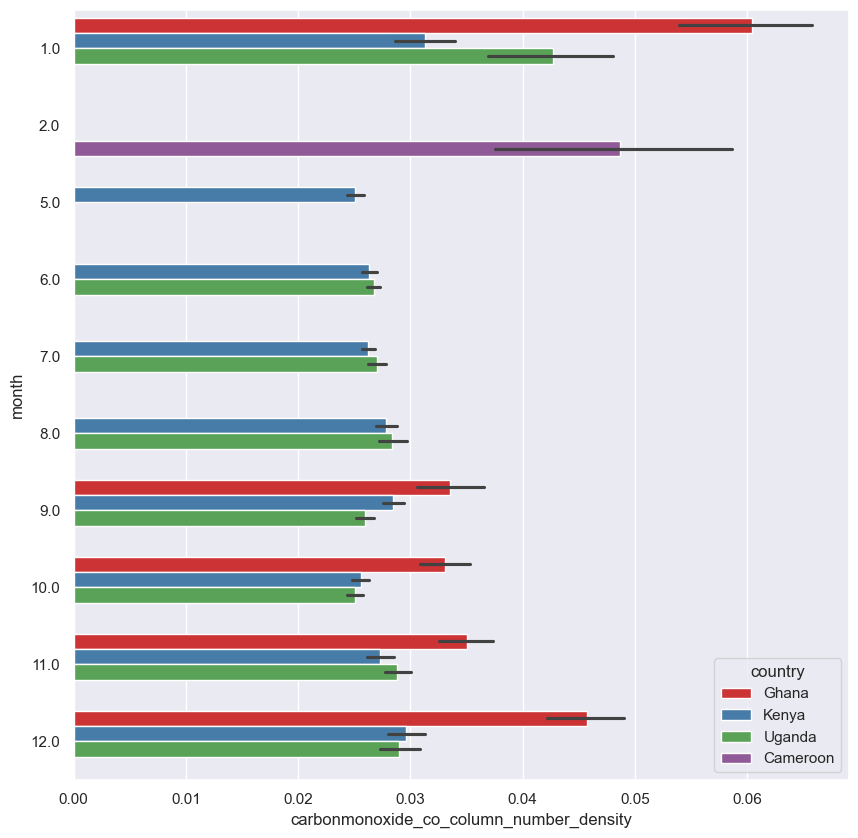

In [63]:
# month vs carbonmonoxide_co_column_number_density vs country
#  kenya as most of the carbonmonoxide in it atmosphere across the whole month of the year
#  ghana experince the large impact of carbomonoxide in the first and last month 
#  cameroon only experience carbonomonoxide on the second month
sns.barplot(y="month", x="carbonmonoxide_co_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set1" )
plt.show()

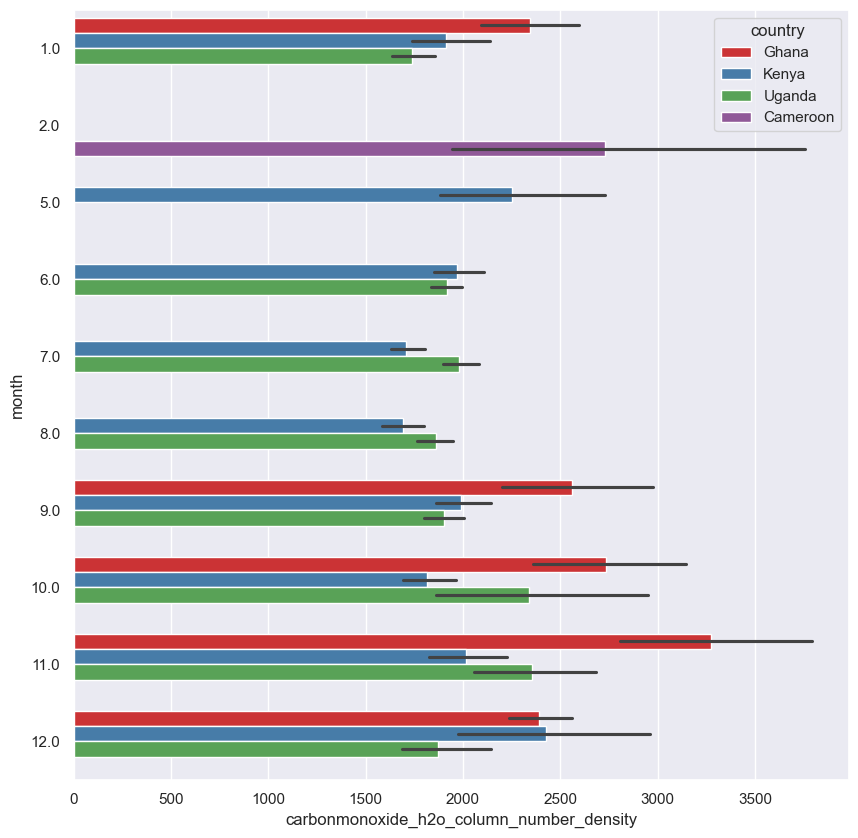

In [64]:
# month vs carbonmonoxide_h2o_column_number_density vs country
#  kenya as most of the carbonmonoxide in it atmosphere across the whole month of the year
#  ghana experince the large impact of carbomonoxide in the first and last month 
#  cameroon only experience carbonomonoxide on the second month

sns.barplot(y="month", x="carbonmonoxide_h2o_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set1" )
plt.show()

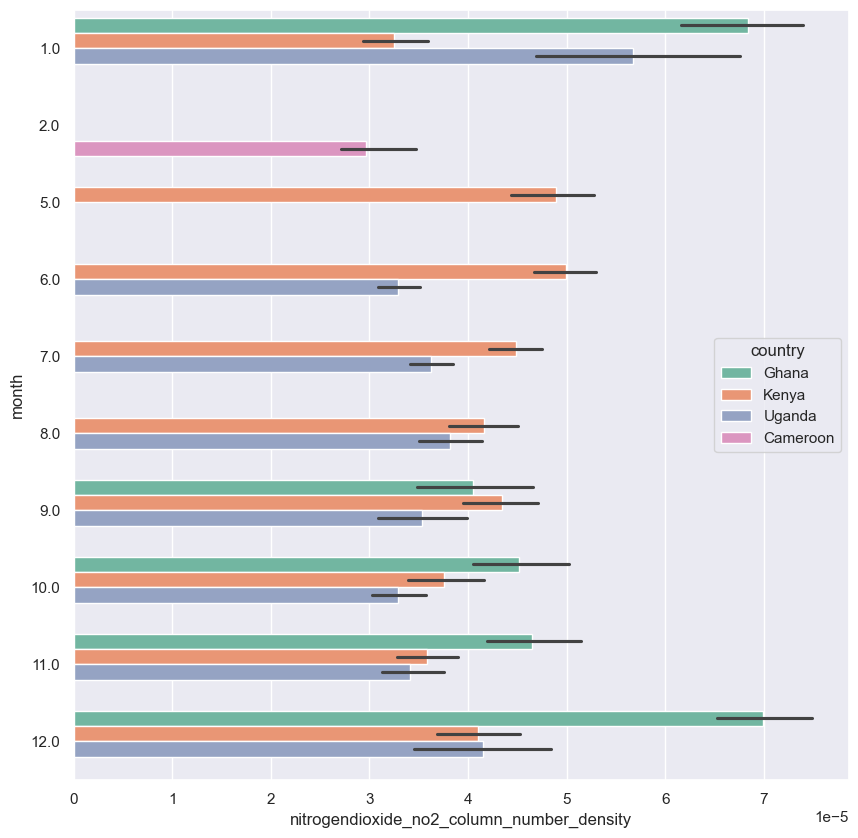

In [65]:
# month vs nitrogendioxide_no2_column_number_density vs country
#  kenya as most of the nitrogendioxide in it atmosphere across the whole month of the year
#  ghana experince the large impact of nitrgendioxide in the first and last month 
#  cameroon only experience nitrogendioxide on the second month
# uganda experience nitrogendioxide month almost all through the month of the year but kenya was more

sns.barplot(y="month", x="nitrogendioxide_no2_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set2" )
plt.show()

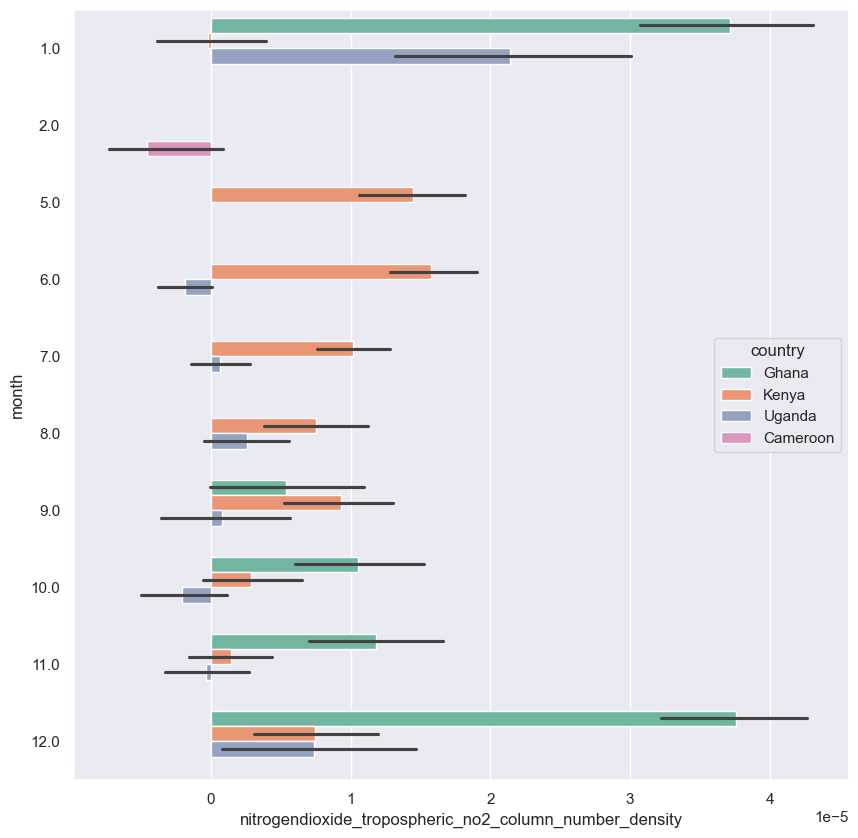

In [66]:
# month vs nitrogendioxide_tropospheric_no2_column_number_density vs country
# mostly kenya ghana as most of nitrogendioxide in there troposhere
# cameroon little to no presence of nitrogendioxide in it troposhere
# uganda just has high presence on the first month of the year which is january
sns.barplot(y="month", x="nitrogendioxide_tropospheric_no2_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set2" )
plt.show()

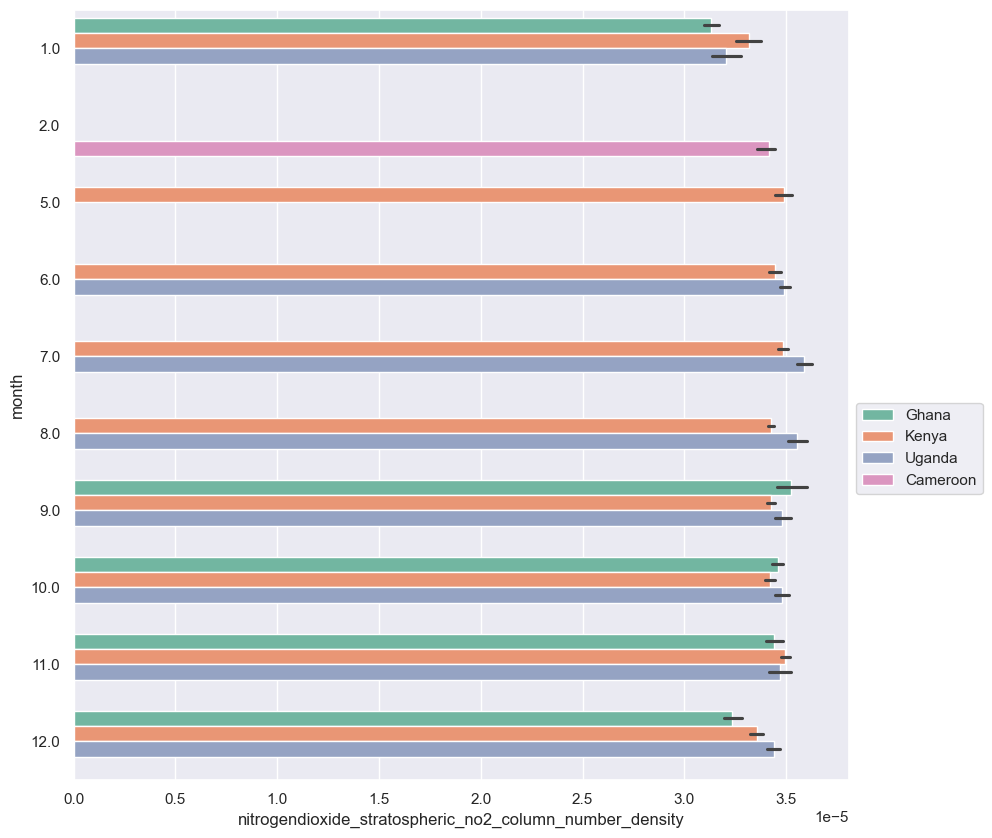

In [67]:
# month vs nitrogendioxide_stratospheric_no2_column_number_density vs country
# most of the country had large amount of nitrogendioxide in there stratosphere
#  cameroon only had in the second month which is feburary
#  kenya and uganda had the presence of there nitrogen in there stratosphere almost all the month of the year
# Ghana presence of nitrogendioxide at the 1st, 9th,10th,11th and 12th month in there stratosphere

sns.barplot(y="month", x="nitrogendioxide_stratospheric_no2_column_number_density",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set2" )
plt.legend(loc="upper left" , bbox_to_anchor =( 1,0.5))
plt.show()

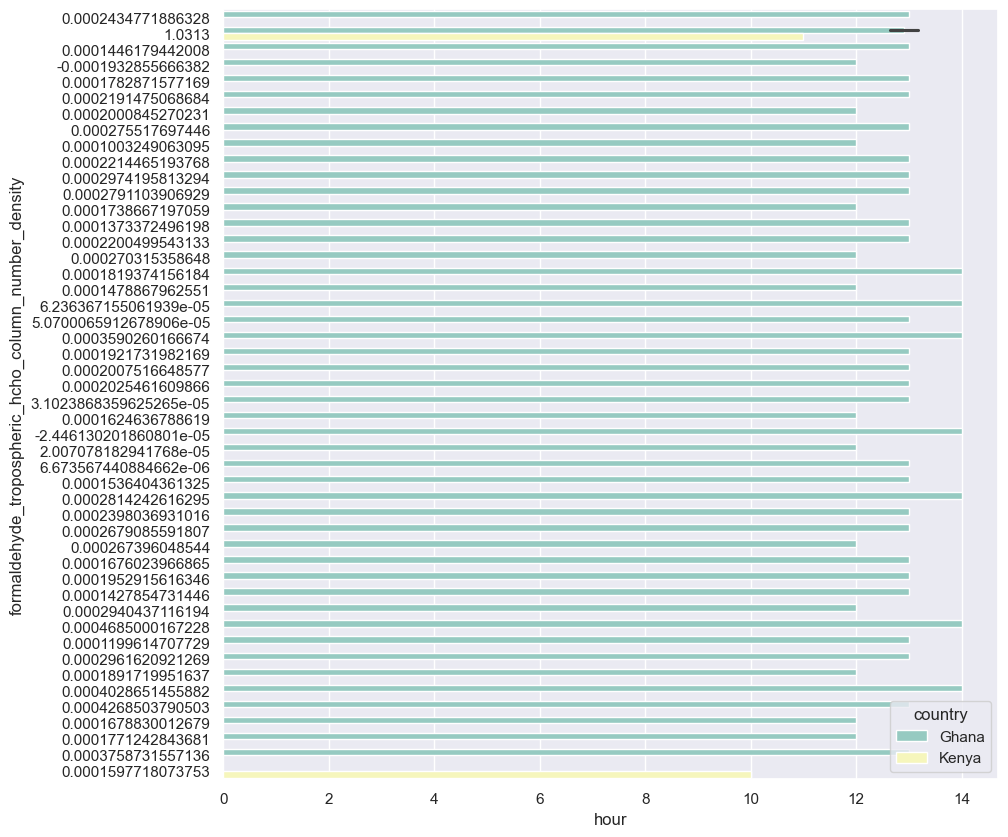

In [68]:
# hour vs formaldehyde_tropospheric_hcho_column_number_density vs country
# kenya as very large amount of formaldehyde in there troposphere
sns.barplot(x="hour", y="formaldehyde_tropospheric_hcho_column_number_density",hue = "country",data= df_test[:60] , orient = "horizontal",palette ="Set3" )
plt.show()

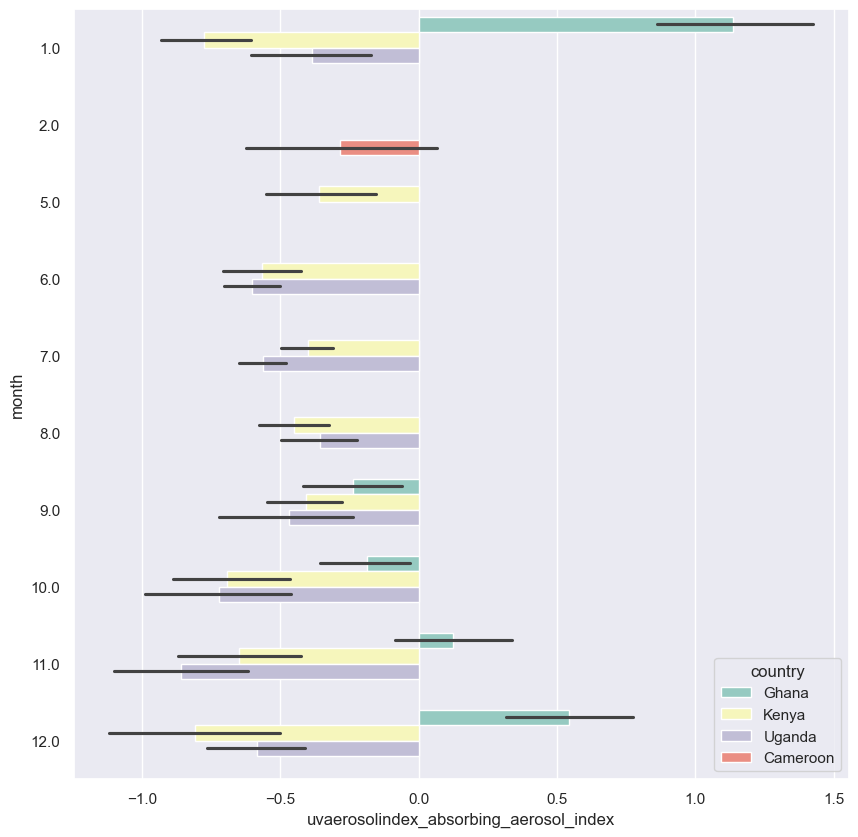

In [69]:
# month vs uvaerosolindex_absorbing_aerosol_index vs country
# ghana presence of increasing absorbsive aerosol  in there
sns.barplot(y="month", x="uvaerosolindex_absorbing_aerosol_index",hue = "country",data= df_test[:1000] , orient = "horizontal",palette ="Set3" )
plt.show()

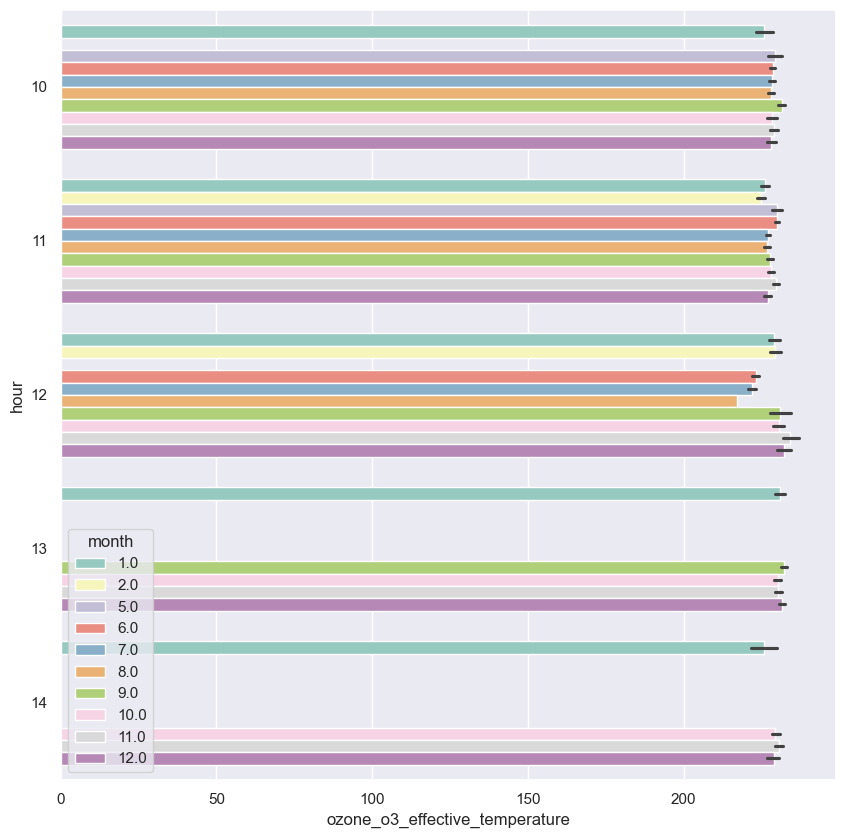

In [70]:
 # month vs ozone_o3_effective_temperature vs hour
 # 14hrs is the longest effective temoerature of the ozone which mostly seen in the  10 to 12th month

sns.barplot(hue="month", x="ozone_o3_effective_temperature",y = "hour",data= df_test[:1000] , orient = "horizontal",palette ="Set3" )
plt.show()

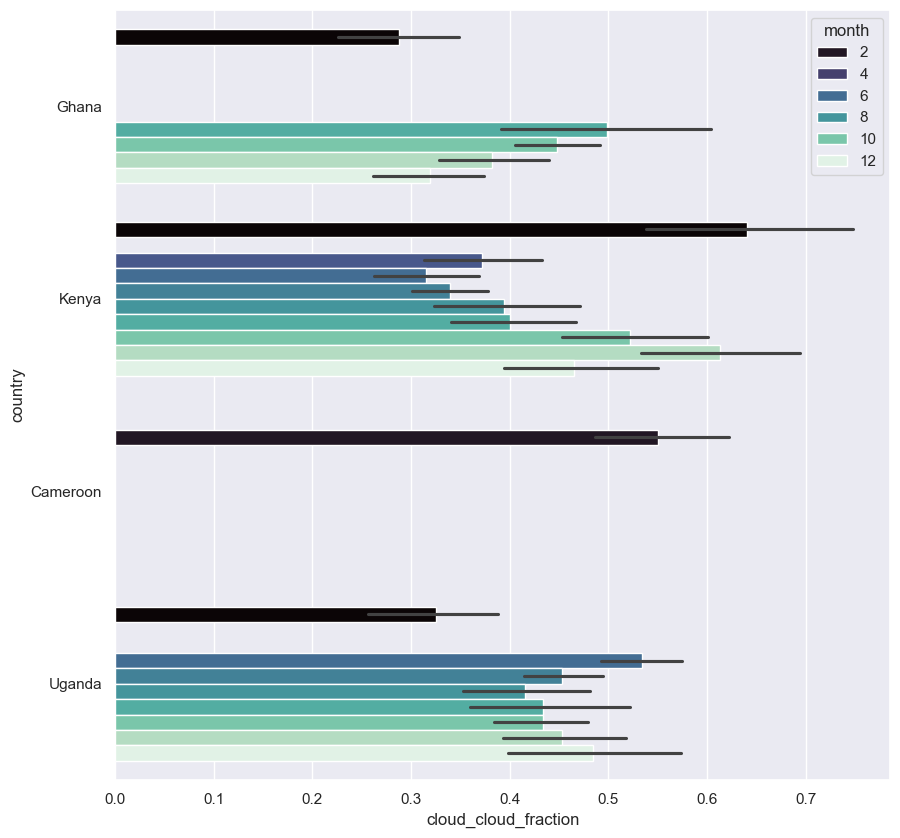

In [71]:
#  month vs cloud_cloud_fraction vs country
#  Uganda and kenya as large cloud cover than any other country
#  cameroon just had the its largest cloud cover on the first month of the year
#  Ghana also had cloud cover in some but it largest was on the 8th month 
sns.barplot(hue="month", x="cloud_cloud_fraction",y = "country",data= df_test[:1000] , orient = "horizontal",palette ="mako" )
plt.show()

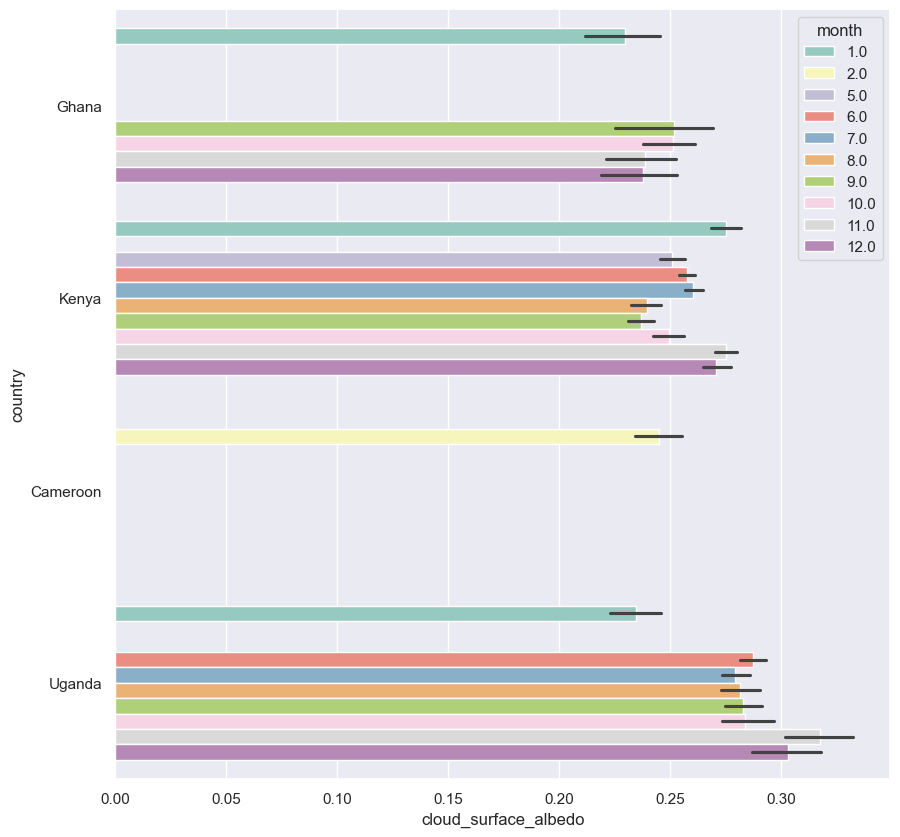

In [72]:
# month vs cloud_surface_albedo vs country
# all the country had this poor reflective cloud almnost all through the month of the year
# tells about the high temperature they experience in the country
sns.barplot(hue="month", x="cloud_surface_albedo",y = "country",data= df_test[:1500] , orient = "horizontal",palette ="Set3" )
plt.show()

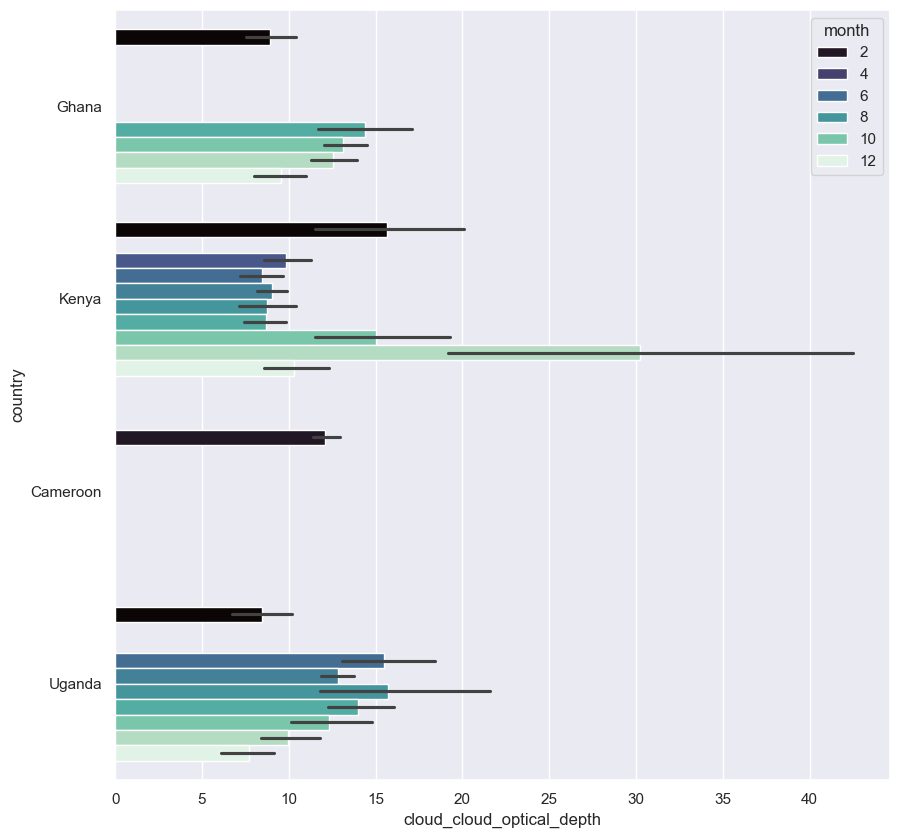

In [73]:
# month vs cloud_surface_albedo vs country
# the reflective properties of the cloud was more in kenya and uganda
sns.barplot(hue="month", x="cloud_cloud_optical_depth",y = "country",data= df_test[:1000] , orient = "horizontal",palette ="mako" )
plt.show()

In [74]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 72 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        2783 non-null   object 
 1   site_id                                                   2783 non-null   object 
 2   site_latitude                                             2783 non-null   float64
 3   site_longitude                                            2783 non-null   float64
 4   city                                                      2783 non-null   object 
 5   country                                                   2783 non-null   object 
 6   date                                                      2783 non-null   object 
 7   hour                                                      2783 non-null   int64  
 8   sulphurdioxide_so2

In [75]:
df_test["date"].unique

<bound method Series.unique of 0       2023-09-06
1       2023-09-07
2       2023-09-08
3       2023-09-09
4       2023-09-20
           ...    
2778    2024-01-27
2779    2024-02-21
2780    2024-02-22
2781    2024-02-23
2782    2024-02-24
Name: date, Length: 2783, dtype: object>

## ENCODING

In [76]:
df_train["site_id"].nunique()

69

In [77]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8071 entries, 0 to 8070
Data columns (total 73 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        8071 non-null   object 
 1   site_id                                                   8071 non-null   object 
 2   site_latitude                                             8071 non-null   float64
 3   site_longitude                                            8071 non-null   float64
 4   city                                                      8071 non-null   object 
 5   country                                                   8071 non-null   object 
 6   date                                                      8071 non-null   object 
 7   hour                                                      8071 non-null   int64  
 8   sulphurdioxide_so2

In [78]:
 cat_features = ['site_id','city','country', 'sulphurdioxide_so2_column_number_density',
       'sulphurdioxide_so2_column_number_density_amf',
       'sulphurdioxide_so2_slant_column_number_density',
       'sulphurdioxide_cloud_fraction', 'sulphurdioxide_sensor_azimuth_angle',
       'sulphurdioxide_sensor_zenith_angle',
       'sulphurdioxide_solar_azimuth_angle',
       'sulphurdioxide_solar_zenith_angle',
       'sulphurdioxide_so2_column_number_density_15km',
       'carbonmonoxide_co_column_number_density',
       'carbonmonoxide_h2o_column_number_density',
       'carbonmonoxide_cloud_height', 'carbonmonoxide_sensor_altitude',
       'carbonmonoxide_sensor_azimuth_angle',
       'carbonmonoxide_sensor_zenith_angle',
       'carbonmonoxide_solar_azimuth_angle',
       'carbonmonoxide_solar_zenith_angle',
       'nitrogendioxide_no2_column_number_density',
       'nitrogendioxide_tropospheric_no2_column_number_density',
       'nitrogendioxide_stratospheric_no2_column_number_density',
       'nitrogendioxide_no2_slant_column_number_density',
       'nitrogendioxide_tropopause_pressure',
       'nitrogendioxide_absorbing_aerosol_index',
       'nitrogendioxide_cloud_fraction', 'nitrogendioxide_sensor_altitude',
       'nitrogendioxide_sensor_azimuth_angle',
       'nitrogendioxide_sensor_zenith_angle',
       'nitrogendioxide_solar_azimuth_angle',
       'nitrogendioxide_solar_zenith_angle',
       'formaldehyde_tropospheric_hcho_column_number_density',
       'formaldehyde_tropospheric_hcho_column_number_density_amf',
       'formaldehyde_hcho_slant_column_number_density',
       'formaldehyde_cloud_fraction', 'formaldehyde_solar_zenith_angle',
       'formaldehyde_solar_azimuth_angle', 'formaldehyde_sensor_zenith_angle',
       'formaldehyde_sensor_azimuth_angle',
       'uvaerosolindex_absorbing_aerosol_index',
       'uvaerosolindex_sensor_altitude', 'uvaerosolindex_sensor_azimuth_angle',
       'uvaerosolindex_sensor_zenith_angle',
       'uvaerosolindex_solar_azimuth_angle',
       'uvaerosolindex_solar_zenith_angle', 'ozone_o3_column_number_density',
       'ozone_o3_column_number_density_amf',
       'ozone_o3_slant_column_number_density',
       'ozone_o3_effective_temperature', 'ozone_cloud_fraction',
       'ozone_sensor_azimuth_angle', 'ozone_sensor_zenith_angle',
       'ozone_solar_azimuth_angle', 'ozone_solar_zenith_angle',
       'cloud_cloud_fraction', 'cloud_cloud_top_pressure',
       'cloud_cloud_top_height', 'cloud_cloud_base_pressure',
       'cloud_cloud_base_height', 'cloud_cloud_optical_depth',
       'cloud_surface_albedo', 'cloud_sensor_azimuth_angle',
       'cloud_sensor_zenith_angle', 'cloud_solar_azimuth_angle',
       'cloud_solar_zenith_angle']

for cat_feature in cat_features:
    df_train[f"{cat_feature}_cat"] = df_train[cat_feature].astype('category')
    df_train[f"{cat_feature}_cat"] = df_train[f"{cat_feature}_cat"].cat.codes


    


C:\Users\PC\AppData\Local\Temp\ipykernel_14124\4038158983.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f"{cat_feature}_cat"] = df_train[cat_feature].astype('category')
C:\Users\PC\AppData\Local\Temp\ipykernel_14124\4038158983.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f"{cat_feature}_cat"] = df_train[cat_feature].astype('category')
C:\Users\PC\AppData\Local\Temp\ipykernel_14124\4038158983.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

In [79]:
df_train.drop(['site_id','id','country','city','sulphurdioxide_so2_column_number_density',
       'sulphurdioxide_so2_column_number_density_amf',
       'sulphurdioxide_so2_slant_column_number_density',
       'sulphurdioxide_cloud_fraction', 'sulphurdioxide_sensor_azimuth_angle',
       'sulphurdioxide_sensor_zenith_angle',
       'sulphurdioxide_solar_azimuth_angle',
       'sulphurdioxide_solar_zenith_angle',
       'sulphurdioxide_so2_column_number_density_15km',
       'carbonmonoxide_co_column_number_density',
       'carbonmonoxide_h2o_column_number_density',
       'carbonmonoxide_cloud_height', 'carbonmonoxide_sensor_altitude',
       'carbonmonoxide_sensor_azimuth_angle',
       'carbonmonoxide_sensor_zenith_angle',
       'carbonmonoxide_solar_azimuth_angle',
       'carbonmonoxide_solar_zenith_angle',
       'nitrogendioxide_no2_column_number_density',
       'nitrogendioxide_tropospheric_no2_column_number_density',
       'nitrogendioxide_stratospheric_no2_column_number_density',
       'nitrogendioxide_no2_slant_column_number_density',
       'nitrogendioxide_tropopause_pressure',
       'nitrogendioxide_absorbing_aerosol_index',
       'nitrogendioxide_cloud_fraction', 'nitrogendioxide_sensor_altitude',
       'nitrogendioxide_sensor_azimuth_angle',
       'nitrogendioxide_sensor_zenith_angle',
       'nitrogendioxide_solar_azimuth_angle',
       'nitrogendioxide_solar_zenith_angle',
       'formaldehyde_tropospheric_hcho_column_number_density',
       'formaldehyde_tropospheric_hcho_column_number_density_amf',
       'formaldehyde_hcho_slant_column_number_density',
       'formaldehyde_cloud_fraction', 'formaldehyde_solar_zenith_angle',
       'formaldehyde_solar_azimuth_angle', 'formaldehyde_sensor_zenith_angle',
       'formaldehyde_sensor_azimuth_angle',
       'uvaerosolindex_absorbing_aerosol_index',
       'uvaerosolindex_sensor_altitude', 'uvaerosolindex_sensor_azimuth_angle',
       'uvaerosolindex_sensor_zenith_angle',
       'uvaerosolindex_solar_azimuth_angle',
       'uvaerosolindex_solar_zenith_angle', 'ozone_o3_column_number_density',
       'ozone_o3_column_number_density_amf',
       'ozone_o3_slant_column_number_density',
       'ozone_o3_effective_temperature', 'ozone_cloud_fraction',
       'ozone_sensor_azimuth_angle', 'ozone_sensor_zenith_angle',
       'ozone_solar_azimuth_angle', 'ozone_solar_zenith_angle',
       'cloud_cloud_fraction', 'cloud_cloud_top_pressure',
       'cloud_cloud_top_height', 'cloud_cloud_base_pressure',
       'cloud_cloud_base_height', 'cloud_cloud_optical_depth',
       'cloud_surface_albedo', 'cloud_sensor_azimuth_angle',
       'cloud_sensor_zenith_angle', 'cloud_solar_azimuth_angle',
       'cloud_solar_zenith_angle'], axis =1 ,inplace =True)
df_train.head()

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_pressure_cat,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat
0,6.53257,3.39936,2023-10-25,13,10.0,12.015000,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
1,6.53257,3.39936,2023-11-02,12,11.0,42.267200,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
2,6.53257,3.39936,2023-11-03,13,11.0,39.450741,56,2,2,2658,...,1358,2729,1358,2729,2718,415,1784,3085,977,3540
3,6.53257,3.39936,2023-11-08,14,11.0,10.537600,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
4,6.53257,3.39936,2023-11-09,13,11.0,19.431731,56,2,2,2100,...,4040,45,4044,44,2476,139,1442,1929,850,3450


In [80]:
df_train.head()

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_pressure_cat,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat
0,6.53257,3.39936,2023-10-25,13,10.0,12.015000,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
1,6.53257,3.39936,2023-11-02,12,11.0,42.267200,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
2,6.53257,3.39936,2023-11-03,13,11.0,39.450741,56,2,2,2658,...,1358,2729,1358,2729,2718,415,1784,3085,977,3540
3,6.53257,3.39936,2023-11-08,14,11.0,10.537600,56,2,2,2658,...,4086,4086,4086,4086,4085,4086,3430,3522,3503,3601
4,6.53257,3.39936,2023-11-09,13,11.0,19.431731,56,2,2,2100,...,4040,45,4044,44,2476,139,1442,1929,850,3450


In [81]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 72 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   id                                                        2783 non-null   object 
 1   site_id                                                   2783 non-null   object 
 2   site_latitude                                             2783 non-null   float64
 3   site_longitude                                            2783 non-null   float64
 4   city                                                      2783 non-null   object 
 5   country                                                   2783 non-null   object 
 6   date                                                      2783 non-null   object 
 7   hour                                                      2783 non-null   int64  
 8   sulphurdioxide_so2

In [82]:
 cat_features = ['site_id','city','country','sulphurdioxide_so2_column_number_density',
       'sulphurdioxide_so2_column_number_density_amf',
       'sulphurdioxide_so2_slant_column_number_density',
       'sulphurdioxide_cloud_fraction', 'sulphurdioxide_sensor_azimuth_angle',
       'sulphurdioxide_sensor_zenith_angle',
       'sulphurdioxide_solar_azimuth_angle',
       'sulphurdioxide_solar_zenith_angle',
       'sulphurdioxide_so2_column_number_density_15km',
       'carbonmonoxide_co_column_number_density',
       'carbonmonoxide_h2o_column_number_density',
       'carbonmonoxide_cloud_height', 'carbonmonoxide_sensor_altitude',
       'carbonmonoxide_sensor_azimuth_angle',
       'carbonmonoxide_sensor_zenith_angle',
       'carbonmonoxide_solar_azimuth_angle',
       'carbonmonoxide_solar_zenith_angle',
       'nitrogendioxide_no2_column_number_density',
       'nitrogendioxide_tropospheric_no2_column_number_density',
       'nitrogendioxide_stratospheric_no2_column_number_density',
       'nitrogendioxide_no2_slant_column_number_density',
       'nitrogendioxide_tropopause_pressure',
       'nitrogendioxide_absorbing_aerosol_index',
       'nitrogendioxide_cloud_fraction', 'nitrogendioxide_sensor_altitude',
       'nitrogendioxide_sensor_azimuth_angle',
       'nitrogendioxide_sensor_zenith_angle',
       'nitrogendioxide_solar_azimuth_angle',
       'nitrogendioxide_solar_zenith_angle',
       'formaldehyde_tropospheric_hcho_column_number_density',
       'formaldehyde_tropospheric_hcho_column_number_density_amf',
       'formaldehyde_hcho_slant_column_number_density',
       'formaldehyde_cloud_fraction', 'formaldehyde_solar_zenith_angle',
       'formaldehyde_solar_azimuth_angle', 'formaldehyde_sensor_zenith_angle',
       'formaldehyde_sensor_azimuth_angle',
       'uvaerosolindex_absorbing_aerosol_index',
       'uvaerosolindex_sensor_altitude', 'uvaerosolindex_sensor_azimuth_angle',
       'uvaerosolindex_sensor_zenith_angle',
       'uvaerosolindex_solar_azimuth_angle',
       'uvaerosolindex_solar_zenith_angle', 'ozone_o3_column_number_density',
       'ozone_o3_column_number_density_amf',
       'ozone_o3_slant_column_number_density',
       'ozone_o3_effective_temperature', 'ozone_cloud_fraction',
       'ozone_sensor_azimuth_angle', 'ozone_sensor_zenith_angle',
       'ozone_solar_azimuth_angle', 'ozone_solar_zenith_angle',
       'cloud_cloud_fraction', 'cloud_cloud_top_pressure',
       'cloud_cloud_top_height', 'cloud_cloud_base_pressure',
       'cloud_cloud_base_height', 'cloud_cloud_optical_depth',
       'cloud_surface_albedo', 'cloud_sensor_azimuth_angle',
       'cloud_sensor_zenith_angle', 'cloud_solar_azimuth_angle',
       'cloud_solar_zenith_angle']
    
for cat_feature in cat_features:
    df_test[f"{cat_feature}_cat"] = df_test[cat_feature].astype('category')
    df_test[f"{cat_feature}_cat"] = df_test[f"{cat_feature}_cat"].cat.codes



C:\Users\PC\AppData\Local\Temp\ipykernel_14124\1718939191.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test[f"{cat_feature}_cat"] = df_test[cat_feature].astype('category')
C:\Users\PC\AppData\Local\Temp\ipykernel_14124\1718939191.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test[f"{cat_feature}_cat"] = df_test[cat_feature].astype('category')
C:\Users\PC\AppData\Local\Temp\ipykernel_14124\1718939191.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

In [83]:
df_test.drop(['site_id','id','country','city','sulphurdioxide_so2_column_number_density',
       'sulphurdioxide_so2_column_number_density_amf',
       'sulphurdioxide_so2_slant_column_number_density',
       'sulphurdioxide_cloud_fraction', 'sulphurdioxide_sensor_azimuth_angle',
       'sulphurdioxide_sensor_zenith_angle',
       'sulphurdioxide_solar_azimuth_angle',
       'sulphurdioxide_solar_zenith_angle',
       'sulphurdioxide_so2_column_number_density_15km',
       'carbonmonoxide_co_column_number_density',
       'carbonmonoxide_h2o_column_number_density',
       'carbonmonoxide_cloud_height', 'carbonmonoxide_sensor_altitude',
       'carbonmonoxide_sensor_azimuth_angle',
       'carbonmonoxide_sensor_zenith_angle',
       'carbonmonoxide_solar_azimuth_angle',
       'carbonmonoxide_solar_zenith_angle',
       'nitrogendioxide_no2_column_number_density',
       'nitrogendioxide_tropospheric_no2_column_number_density',
       'nitrogendioxide_stratospheric_no2_column_number_density',
       'nitrogendioxide_no2_slant_column_number_density',
       'nitrogendioxide_tropopause_pressure',
       'nitrogendioxide_absorbing_aerosol_index',
       'nitrogendioxide_cloud_fraction', 'nitrogendioxide_sensor_altitude',
       'nitrogendioxide_sensor_azimuth_angle',
       'nitrogendioxide_sensor_zenith_angle',
       'nitrogendioxide_solar_azimuth_angle',
       'nitrogendioxide_solar_zenith_angle',
       'formaldehyde_tropospheric_hcho_column_number_density',
       'formaldehyde_tropospheric_hcho_column_number_density_amf',
       'formaldehyde_hcho_slant_column_number_density',
       'formaldehyde_cloud_fraction', 'formaldehyde_solar_zenith_angle',
       'formaldehyde_solar_azimuth_angle', 'formaldehyde_sensor_zenith_angle',
       'formaldehyde_sensor_azimuth_angle',
       'uvaerosolindex_absorbing_aerosol_index',
       'uvaerosolindex_sensor_altitude', 'uvaerosolindex_sensor_azimuth_angle',
       'uvaerosolindex_sensor_zenith_angle',
       'uvaerosolindex_solar_azimuth_angle',
       'uvaerosolindex_solar_zenith_angle', 'ozone_o3_column_number_density',
       'ozone_o3_column_number_density_amf',
       'ozone_o3_slant_column_number_density',
       'ozone_o3_effective_temperature', 'ozone_cloud_fraction',
       'ozone_sensor_azimuth_angle', 'ozone_sensor_zenith_angle',
       'ozone_solar_azimuth_angle', 'ozone_solar_zenith_angle',
       'cloud_cloud_fraction', 'cloud_cloud_top_pressure',
       'cloud_cloud_top_height', 'cloud_cloud_base_pressure',
       'cloud_cloud_base_height', 'cloud_cloud_optical_depth',
       'cloud_surface_albedo', 'cloud_sensor_azimuth_angle',
       'cloud_sensor_zenith_angle', 'cloud_solar_azimuth_angle',
       'cloud_solar_zenith_angle'], axis =1 ,inplace =True)

df_test.head()

,site_latitude,site_longitude,date,hour,month,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,sulphurdioxide_so2_column_number_density_amf_cat,...,cloud_cloud_top_pressure_cat,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat
0,5.61252,-0.22955,2023-09-06,13,9.0,27,0,1,520,1125,...,1066,141,1083,130,133,563,55,71,446,328
1,5.61252,-0.22955,2023-09-07,13,9.0,27,0,1,344,941,...,537,731,544,738,896,566,515,485,456,547
2,5.61252,-0.22955,2023-09-08,13,9.0,27,0,1,561,1368,...,537,731,544,738,896,566,515,485,456,547
3,5.61252,-0.22955,2023-09-09,12,9.0,27,0,1,344,941,...,327,874,326,874,1131,1022,549,884,431,6
4,5.61252,-0.22955,2023-09-20,12,9.0,27,0,1,29,703,...,537,731,544,738,896,566,515,485,456,547


In [84]:
# converting date from object to daytime series
df_train["date"] = pd.to_datetime(df_train["date"])

In [85]:
df_train["date"].dtype 

dtype('<M8[ns]')

In [86]:
# finding the unique values of date
df_train["date"].dt.year.unique()

array([2023, 2024], dtype=int32)

In [87]:
# creating a new variable called date
df_train["year"] =df_train["date"].dt.year 

In [88]:
df_train["date"] = (df_train["date"] - pd.Timestamp("2023-01-3")) /pd.Timedelta(days =1)

In [89]:
df_train.head()

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
0,6.53257,3.39936,295.0,13,10.0,12.015000,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
1,6.53257,3.39936,303.0,12,11.0,42.267200,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
2,6.53257,3.39936,304.0,13,11.0,39.450741,56,2,2,2658,...,2729,1358,2729,2718,415,1784,3085,977,3540,2023
3,6.53257,3.39936,309.0,14,11.0,10.537600,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
4,6.53257,3.39936,310.0,13,11.0,19.431731,56,2,2,2100,...,45,4044,44,2476,139,1442,1929,850,3450,2023


In [90]:
df_test["date"].unique

<bound method Series.unique of 0       2023-09-06
1       2023-09-07
2       2023-09-08
3       2023-09-09
4       2023-09-20
           ...    
2778    2024-01-27
2779    2024-02-21
2780    2024-02-22
2781    2024-02-23
2782    2024-02-24
Name: date, Length: 2783, dtype: object>

In [91]:
# converting date from object to daytime series
df_test["date"] = pd.to_datetime(df_test["date"])

In [92]:
df_test["date"].dtype 

dtype('<M8[ns]')

In [93]:
# creating a new variable called date
df_test["year"] =df_test["date"].dt.year 

In [94]:
df_test["date"].dt.year.unique()

array([2023, 2024], dtype=int32)

In [95]:
df_test["date"] = (df_test["date"] - pd.Timestamp("2023-01-03")) /pd.Timedelta(days =1)

In [96]:
df_test.head()

,site_latitude,site_longitude,date,hour,month,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,sulphurdioxide_so2_column_number_density_amf_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
0,5.61252,-0.22955,246.0,13,9.0,27,0,1,520,1125,...,141,1083,130,133,563,55,71,446,328,2023
1,5.61252,-0.22955,247.0,13,9.0,27,0,1,344,941,...,731,544,738,896,566,515,485,456,547,2023
2,5.61252,-0.22955,248.0,13,9.0,27,0,1,561,1368,...,731,544,738,896,566,515,485,456,547,2023
3,5.61252,-0.22955,249.0,12,9.0,27,0,1,344,941,...,874,326,874,1131,1022,549,884,431,6,2023
4,5.61252,-0.22955,260.0,12,9.0,27,0,1,29,703,...,731,544,738,896,566,515,485,456,547,2023


In [97]:
df_train.describe()

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
count,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,...,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000
mean,0.635678,30.246982,202.521001,10.877463,6.122414,24.639296,22.627432,1.462025,2.477016,2139.442448,...,2853.584066,2789.320654,2853.626812,2822.896295,2844.293644,2369.337257,2494.101227,2412.117086,2478.289431,2023.097262
std,2.154605,9.393151,111.205825,0.815875,3.420636,24.878920,14.462414,0.806734,0.844215,806.165479,...,1336.871731,1373.719972,1336.759016,1364.000950,1337.454975,1118.569768,1134.836828,1169.063547,1210.155666,0.296332
min,-3.459970,3.201510,-2.000000,10.000000,1.000000,1.200000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000
25%,0.288630,32.568643,120.000000,10.000000,3.000000,13.270600,11.000000,1.000000,2.000000,1709.500000,...,1734.500000,1584.500000,1734.500000,1639.500000,1700.500000,1433.500000,1557.500000,1400.500000,1425.000000,2023.000000
50%,0.332610,32.600480,194.000000,11.000000,6.000000,18.375400,21.000000,1.000000,3.000000,2658.000000,...,3339.000000,3240.000000,3339.000000,3322.000000,3312.000000,2702.000000,2931.000000,2807.000000,2921.000000,2023.000000
75%,0.374653,32.641110,296.000000,11.000000,9.000000,28.838400,32.000000,2.000000,3.000000,2658.000000,...,4086.000000,4086.000000,4086.000000,4085.000000,4086.000000,3430.000000,3522.000000,3503.000000,3601.000000,2023.000000
max,6.595400,36.914272,419.000000,14.000000,12.000000,456.193333,68.000000,3.000000,3.000000,2658.000000,...,4086.000000,4086.000000,4086.000000,4085.000000,4086.000000,3430.000000,3522.000000,3503.000000,3601.000000,2024.000000


In [98]:
df_test.describe()

,site_latitude,site_longitude,date,hour,month,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,sulphurdioxide_so2_column_number_density_amf_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
count,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,...,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.00000,2783.000000,2783.000000,2783.000000,2783.000000
mean,1.549512,28.547601,255.718649,10.968020,7.916277,13.223859,1.465685,2.071865,555.439813,796.300036,...,672.844053,565.599353,676.311534,729.562702,574.450234,506.19691,507.747395,484.592526,542.630255,2023.094143
std,2.113084,12.401021,75.800152,0.974542,3.031200,8.145636,0.761793,0.683488,356.369860,345.553945,...,259.479895,254.367587,259.923810,303.733165,256.760974,206.77447,213.592211,214.974168,222.754604,0.292080
min,-0.140730,-0.260570,118.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2023.000000
25%,-0.101823,32.300407,188.000000,10.000000,6.000000,6.000000,1.000000,2.000000,344.000000,567.500000,...,586.500000,528.000000,588.500000,531.500000,517.500000,450.00000,485.000000,456.000000,505.000000,2023.000000
50%,-0.070787,34.752824,246.000000,11.000000,8.000000,13.000000,2.000000,2.000000,344.000000,941.000000,...,731.000000,544.000000,738.000000,896.000000,566.000000,515.00000,485.000000,456.000000,547.000000,2023.000000
75%,2.789675,34.762048,318.000000,11.000000,10.000000,19.000000,2.000000,3.000000,826.500000,941.000000,...,731.000000,620.500000,738.000000,896.000000,617.000000,524.50000,581.000000,551.000000,587.500000,2023.000000
max,5.651470,34.803285,417.000000,14.000000,12.000000,38.000000,3.000000,3.000000,1372.000000,1446.000000,...,1208.000000,1208.000000,1208.000000,1207.000000,1205.000000,993.00000,1013.000000,1011.000000,1051.000000,2024.000000


##  Heat Map

In [99]:
#using the corr map to find their relationship
df_train_corr=df_train.corr()
df_train_corr

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
site_latitude,1.000000,-0.962193,0.227213,0.704178,0.172595,0.288082,0.384418,-0.015092,0.149056,-0.112263,...,0.057558,0.061354,0.056684,0.057581,-0.060109,0.064678,0.105737,-0.062954,0.075574,0.065232
site_longitude,-0.962193,1.000000,-0.308624,-0.737978,-0.229735,-0.305682,-0.544023,-0.049989,0.054472,0.106293,...,-0.041755,-0.096014,-0.040763,-0.080404,0.080087,-0.087160,-0.113134,0.067816,-0.098944,-0.093636
date,0.227213,-0.308624,1.000000,0.192796,0.486973,0.194709,0.382088,0.215062,-0.302833,-0.030548,...,-0.079131,0.069530,-0.078810,-0.021869,-0.109536,0.075126,0.015207,-0.183554,0.030586,0.558751
hour,0.704178,-0.737978,0.192796,1.000000,0.154475,0.191801,0.412798,0.051574,-0.063009,-0.042132,...,0.097257,0.300475,0.096829,0.225405,0.080061,-0.038293,0.178018,0.109010,0.491035,0.050327
month,0.172595,-0.229735,0.486973,0.154475,1.000000,-0.013991,0.301622,0.278790,-0.299015,0.031976,...,-0.119596,0.061215,-0.120537,0.061250,-0.044174,0.016005,-0.012549,-0.010532,0.091383,-0.448905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cloud_sensor_azimuth_angle_cat,0.064678,-0.087160,0.075126,-0.038293,0.016005,0.044025,0.134096,0.144660,-0.141737,-0.174870,...,0.557369,0.534974,0.556880,0.538823,0.482327,1.000000,0.628678,0.523228,0.328064,0.063038
cloud_sensor_zenith_angle_cat,0.105737,-0.113134,0.015207,0.178018,-0.012549,0.034134,0.059801,-0.018362,0.004518,-0.107149,...,0.564666,0.478490,0.564453,0.583776,0.613781,0.628678,1.000000,0.501492,0.516040,0.029335
cloud_solar_azimuth_angle_cat,-0.062954,0.067816,-0.183554,0.109010,-0.010532,-0.086877,-0.030411,0.044877,-0.024481,-0.101809,...,0.500923,0.572226,0.500683,0.568328,0.619165,0.523228,0.501492,1.000000,0.552626,-0.175069
cloud_solar_zenith_angle_cat,0.075574,-0.098944,0.030586,0.491035,0.091383,0.015479,0.135124,0.122000,-0.127106,-0.103828,...,0.399155,0.663059,0.399394,0.541532,0.528275,0.328064,0.516040,0.552626,1.000000,-0.051206


In [100]:
#using the corr map to find their relationship
df_test_corr=df_test.corr()
df_test_corr

,site_latitude,site_longitude,date,hour,month,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,sulphurdioxide_so2_column_number_density_amf_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
site_latitude,1.000000,-0.864762,0.257978,0.715523,0.087582,0.611362,-0.914747,-0.253257,0.015157,0.212933,...,-0.126624,0.147273,-0.129533,0.161467,0.054456,-0.090993,-0.003212,-0.174625,-0.054798,0.104085
site_longitude,-0.864762,1.000000,-0.364794,-0.838118,-0.115957,-0.646040,0.771117,0.686233,-0.090978,-0.007998,...,0.035444,-0.057698,0.036308,-0.099746,0.143128,0.056311,-0.023195,0.246115,0.015830,-0.155015
date,0.257978,-0.364794,1.000000,0.243821,0.169953,0.392153,-0.144664,-0.381741,0.038308,0.079917,...,0.088261,-0.082228,0.087478,0.047573,-0.020217,0.108104,-0.002250,-0.655262,-0.001351,0.555159
hour,0.715523,-0.838118,0.243821,1.000000,0.102523,0.525439,-0.647131,-0.580989,0.072231,-0.076583,...,-0.060297,0.092532,-0.057438,0.082618,-0.188751,-0.354547,-0.028130,-0.195503,0.308693,0.085087
month,0.087582,-0.115957,0.169953,0.102523,1.000000,0.061961,-0.196215,-0.018782,0.026714,0.115232,...,0.099082,-0.099724,0.099627,0.020191,0.073105,-0.019474,0.052742,-0.169830,0.146950,-0.721895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cloud_sensor_azimuth_angle_cat,-0.090993,0.056311,0.108104,-0.354547,-0.019474,-0.026283,0.065355,-0.005790,0.008435,0.070047,...,0.184800,-0.178151,0.183574,0.062456,0.133342,1.000000,0.107509,-0.049558,-0.582250,0.089219
cloud_sensor_zenith_angle_cat,-0.003212,-0.023195,-0.002250,-0.028130,0.052742,-0.003061,-0.005593,-0.040027,-0.026930,-0.115864,...,0.064953,-0.080171,0.066349,-0.001285,0.165802,0.107509,1.000000,0.004710,0.079589,-0.046980
cloud_solar_azimuth_angle_cat,-0.174625,0.246115,-0.655262,-0.195503,-0.169830,-0.234644,0.136086,0.231711,-0.007042,-0.051920,...,-0.140234,0.127395,-0.141832,-0.035105,0.061649,-0.049558,0.004710,1.000000,-0.149527,-0.314088
cloud_solar_zenith_angle_cat,-0.054798,0.015830,-0.001351,0.308693,0.146950,-0.061010,0.022429,-0.024273,0.011462,-0.120954,...,-0.069339,0.064510,-0.063780,-0.225008,-0.096402,-0.582250,0.079589,-0.149527,1.000000,-0.122463


In [101]:
df_train.head()

,site_latitude,site_longitude,date,hour,month,pm2_5,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
0,6.53257,3.39936,295.0,13,10.0,12.015000,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
1,6.53257,3.39936,303.0,12,11.0,42.267200,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
2,6.53257,3.39936,304.0,13,11.0,39.450741,56,2,2,2658,...,2729,1358,2729,2718,415,1784,3085,977,3540,2023
3,6.53257,3.39936,309.0,14,11.0,10.537600,56,2,2,2658,...,4086,4086,4086,4085,4086,3430,3522,3503,3601,2023
4,6.53257,3.39936,310.0,13,11.0,19.431731,56,2,2,2100,...,45,4044,44,2476,139,1442,1929,850,3450,2023


## Data Segment

In [102]:
y = df_train["pm2_5"] # Target
x = df_train.drop("pm2_5", axis=1)

In [103]:
scaler =StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


In [104]:
df_train_normalize =pd.DataFrame(scaler.fit_transform(x), columns = x.columns)
df_train_normalize

,site_latitude,site_longitude,date,hour,month,site_id_cat,city_cat,country_cat,sulphurdioxide_so2_column_number_density_cat,sulphurdioxide_so2_column_number_density_amf_cat,...,cloud_cloud_top_height_cat,cloud_cloud_base_pressure_cat,cloud_cloud_base_height_cat,cloud_cloud_optical_depth_cat,cloud_surface_albedo_cat,cloud_sensor_azimuth_angle_cat,cloud_sensor_zenith_angle_cat,cloud_solar_azimuth_angle_cat,cloud_solar_zenith_angle_cat,year
0,2.737049,-2.858390,0.831654,2.601709,1.133657,2.307681,0.666898,-0.565076,0.643279,0.644821,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,-0.328239
1,2.737049,-2.858390,0.903597,1.375955,1.426018,2.307681,0.666898,-0.565076,0.643279,0.644821,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,-0.328239
2,2.737049,-2.858390,0.912590,2.601709,1.426018,2.307681,0.666898,-0.565076,0.643279,0.644821,...,-0.093197,-1.041995,-0.093236,-0.076908,-1.816468,-0.523323,0.520723,-1.227654,0.877388,-0.328239
3,2.737049,-2.858390,0.957554,3.827463,1.426018,2.307681,0.666898,-0.565076,0.643279,0.644821,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,-0.328239
4,2.737049,-2.858390,0.966547,2.601709,1.426018,2.307681,0.666898,-0.565076,-0.048929,-0.115086,...,-2.100993,0.913401,-2.101950,-0.254338,-2.022843,-0.829090,-0.497989,-1.336295,0.803013,-0.328239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8066,-0.884001,0.699719,1.587057,-1.075553,-1.497596,1.132147,1.906541,-1.749681,0.643279,0.644821,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,3.046560
8067,-0.884001,0.699719,1.650007,0.150201,-1.497596,1.132147,1.906541,-1.749681,-2.527482,-1.768093,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,3.046560
8068,-0.884001,0.699719,1.659000,0.150201,-1.497596,1.132147,1.906541,-1.749681,0.643279,0.644821,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,3.046560
8069,-0.884001,0.699719,1.667993,-1.075553,-1.497596,1.132147,1.906541,-1.749681,-1.799298,-0.367199,...,0.921923,0.943977,0.921968,0.925353,0.928467,0.948290,0.905824,0.933183,0.927798,3.046560


In [105]:
#spliting the data into training and testing data
x_df_train, x_df_test, y_df_train, y_df_test = train_test_split(df_train_normalize, y, test_size=0.2, random_state=42)

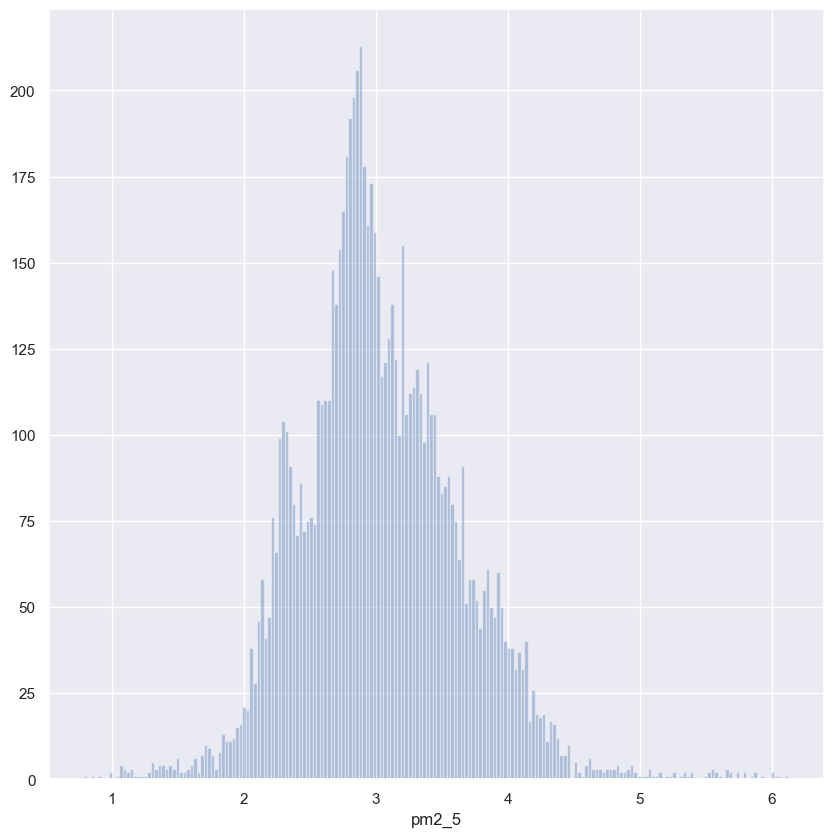

In [106]:
df_train['pm2_5'] = np.log(df_train['pm2_5'].values + 1)
sns.distplot(df_train['pm2_5'], kde = False, bins = 200)
plt.show()

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

clf = LinearRegression()
clf.fit(x_df_train, y_df_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
y_pred = clf.predict(x_df_test)
y_pred

array([30.41552763, 20.12033145, 32.72765143, ..., 16.16300031,
       36.99576131, 17.00507362], shape=(1615,))

In [109]:
y_pred = clf.predict(x_df_test)

k = np.sqrt(mean_squared_error(y_df_test, y_pred))
print('RMSE ', k )

RMSE  24.352372726427856


In [110]:
from sklearn.neighbors import KNeighborsRegressor as KNN

# Creating instance of KNN
clf = KNN(n_neighbors =3,p=2,weights="distance",n_jobs=-1,algorithm= 'auto')

# Fitting the model
clf.fit(x_df_train,y_df_train)

# Predicting over the Train Set and calculating F1
test_predict = clf.predict(x_df_train)
k = np.sqrt(mean_squared_error(y_df_test, y_pred))
print('RMSE ', k )

C:\Users\PC\miniconda3\envs\geoenv\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


RMSE  24.352372726427856


In [111]:
from sklearn.tree import DecisionTreeRegressor

clf = DecisionTreeRegressor(max_depth= 3,random_state =1000,min_samples_split=3,
    min_samples_leaf=2)
clf.fit(x_df_train, y_df_train)
y_pred = clf.predict(x_df_test)

print("RMSE", np.sqrt(mean_squared_error(y_df_test, y_pred)))


RMSE 23.87612657839415


In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Create a Random Forest Regression model
model = RandomForestRegressor(n_estimators=1000, criterion ="poisson", verbose=3, min_samples_leaf =10, max_depth=3, random_state=42)

# Train the model
model.fit(x_df_train, y_df_train)

# Make predictions on the test set
y_pred = model.predict(x_df_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_df_test, y_pred))
print("Root Mean Squared Error:", rmse)


building tree 1 of 1000
building tree 2 of 1000
building tree 3 of 1000
building tree 4 of 1000
building tree 5 of 1000
building tree 6 of 1000
building tree 7 of 1000
building tree 8 of 1000
building tree 9 of 1000
building tree 10 of 1000
building tree 11 of 1000
building tree 12 of 1000
building tree 13 of 1000
building tree 14 of 1000
building tree 15 of 1000
building tree 16 of 1000
building tree 17 of 1000
building tree 18 of 1000
building tree 19 of 1000
building tree 20 of 1000
building tree 21 of 1000
building tree 22 of 1000
building tree 23 of 1000
building tree 24 of 1000
building tree 25 of 1000
building tree 26 of 1000
building tree 27 of 1000
building tree 28 of 1000
building tree 29 of 1000
building tree 30 of 1000
building tree 31 of 1000


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    4.2s


building tree 32 of 1000
building tree 33 of 1000
building tree 34 of 1000
building tree 35 of 1000
building tree 36 of 1000
building tree 37 of 1000
building tree 38 of 1000
building tree 39 of 1000
building tree 40 of 1000
building tree 41 of 1000
building tree 42 of 1000
building tree 43 of 1000
building tree 44 of 1000
building tree 45 of 1000
building tree 46 of 1000
building tree 47 of 1000
building tree 48 of 1000
building tree 49 of 1000
building tree 50 of 1000
building tree 51 of 1000
building tree 52 of 1000
building tree 53 of 1000
building tree 54 of 1000
building tree 55 of 1000
building tree 56 of 1000
building tree 57 of 1000
building tree 58 of 1000
building tree 59 of 1000
building tree 60 of 1000
building tree 61 of 1000
building tree 62 of 1000
building tree 63 of 1000
building tree 64 of 1000
building tree 65 of 1000
building tree 66 of 1000
building tree 67 of 1000
building tree 68 of 1000
building tree 69 of 1000
building tree 70 of 1000
building tree 71 of 1000


[Parallel(n_jobs=1)]: Done 127 tasks      | elapsed:   17.3s


building tree 129 of 1000
building tree 130 of 1000
building tree 131 of 1000
building tree 132 of 1000
building tree 133 of 1000
building tree 134 of 1000
building tree 135 of 1000
building tree 136 of 1000
building tree 137 of 1000
building tree 138 of 1000
building tree 139 of 1000
building tree 140 of 1000
building tree 141 of 1000
building tree 142 of 1000
building tree 143 of 1000
building tree 144 of 1000
building tree 145 of 1000
building tree 146 of 1000
building tree 147 of 1000
building tree 148 of 1000
building tree 149 of 1000
building tree 150 of 1000
building tree 151 of 1000
building tree 152 of 1000
building tree 153 of 1000
building tree 154 of 1000
building tree 155 of 1000
building tree 156 of 1000
building tree 157 of 1000
building tree 158 of 1000
building tree 159 of 1000
building tree 160 of 1000
building tree 161 of 1000
building tree 162 of 1000
building tree 163 of 1000
building tree 164 of 1000
building tree 165 of 1000
building tree 166 of 1000
building tre

[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:   38.5s


building tree 289 of 1000
building tree 290 of 1000
building tree 291 of 1000
building tree 292 of 1000
building tree 293 of 1000
building tree 294 of 1000
building tree 295 of 1000
building tree 296 of 1000
building tree 297 of 1000
building tree 298 of 1000
building tree 299 of 1000
building tree 300 of 1000
building tree 301 of 1000
building tree 302 of 1000
building tree 303 of 1000
building tree 304 of 1000
building tree 305 of 1000
building tree 306 of 1000
building tree 307 of 1000
building tree 308 of 1000
building tree 309 of 1000
building tree 310 of 1000
building tree 311 of 1000
building tree 312 of 1000
building tree 313 of 1000
building tree 314 of 1000
building tree 315 of 1000
building tree 316 of 1000
building tree 317 of 1000
building tree 318 of 1000
building tree 319 of 1000
building tree 320 of 1000
building tree 321 of 1000
building tree 322 of 1000
building tree 323 of 1000
building tree 324 of 1000
building tree 325 of 1000
building tree 326 of 1000
building tre

[Parallel(n_jobs=1)]: Done 511 tasks      | elapsed:  1.1min


building tree 513 of 1000
building tree 514 of 1000
building tree 515 of 1000
building tree 516 of 1000
building tree 517 of 1000
building tree 518 of 1000
building tree 519 of 1000
building tree 520 of 1000
building tree 521 of 1000
building tree 522 of 1000
building tree 523 of 1000
building tree 524 of 1000
building tree 525 of 1000
building tree 526 of 1000
building tree 527 of 1000
building tree 528 of 1000
building tree 529 of 1000
building tree 530 of 1000
building tree 531 of 1000
building tree 532 of 1000
building tree 533 of 1000
building tree 534 of 1000
building tree 535 of 1000
building tree 536 of 1000
building tree 537 of 1000
building tree 538 of 1000
building tree 539 of 1000
building tree 540 of 1000
building tree 541 of 1000
building tree 542 of 1000
building tree 543 of 1000
building tree 544 of 1000
building tree 545 of 1000
building tree 546 of 1000
building tree 547 of 1000
building tree 548 of 1000
building tree 549 of 1000
building tree 550 of 1000
building tre

[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:  1.6min


building tree 801 of 1000
building tree 802 of 1000
building tree 803 of 1000
building tree 804 of 1000
building tree 805 of 1000
building tree 806 of 1000
building tree 807 of 1000
building tree 808 of 1000
building tree 809 of 1000
building tree 810 of 1000
building tree 811 of 1000
building tree 812 of 1000
building tree 813 of 1000
building tree 814 of 1000
building tree 815 of 1000
building tree 816 of 1000
building tree 817 of 1000
building tree 818 of 1000
building tree 819 of 1000
building tree 820 of 1000
building tree 821 of 1000
building tree 822 of 1000
building tree 823 of 1000
building tree 824 of 1000
building tree 825 of 1000
building tree 826 of 1000
building tree 827 of 1000
building tree 828 of 1000
building tree 829 of 1000
building tree 830 of 1000
building tree 831 of 1000
building tree 832 of 1000
building tree 833 of 1000
building tree 834 of 1000
building tree 835 of 1000
building tree 836 of 1000
building tree 837 of 1000
building tree 838 of 1000
building tre

[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed:  2.0min finished
[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 127 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 511 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


In [113]:
from sklearn.svm import SVR

sv_reg = SVR(kernel='rbf', gamma ='auto',verbose=False)
sv_reg.fit(x_df_train, y_df_train)
y_pred = sv_reg.predict(x_df_test)
k = np.sqrt(mean_squared_error(y_df_test, y_pred))
print('RMSE ', k )


RMSE  24.962207931116644


In [114]:
from sklearn.ensemble import GradientBoostingRegressor
import time

start = time.time()
gbm = GradientBoostingRegressor(n_estimators =500)

gbm.fit(x_df_train ,y_df_train)
y_pred =gbm.predict(x_df_test)

print("RMSE_score", np.sqrt(mean_squared_error(y_df_test, y_pred)))

end =time.time()
diff =end - start
print("Execution time :", diff)

RMSE_score 18.952557326327025
Execution time : 76.56739163398743


In [122]:
df_sample = pd.read_csv("SampleSubmission.csv")
df_sample.head(5)

,id,pm2_5
0,id_ihxgrbq8bw,58.214265
1,id_dg6s4fhiwe,58.214265
2,id_f7hwwtmuzp,58.214265
3,id_ioese5awdg,58.214265
4,id_hdw320zpls,60.031562


In [123]:
df_sample = pd.read_csv("SampleSubmission.csv")
df_sample.head(5)

,id,pm2_5
0,id_ihxgrbq8bw,58.214265
1,id_dg6s4fhiwe,58.214265
2,id_f7hwwtmuzp,58.214265
3,id_ioese5awdg,58.214265
4,id_hdw320zpls,60.031562


In [124]:
df_pred = gbm.predict(df_test)

In [125]:
df_pred

array([248.20796903, 248.20796903, 248.20796903, ..., 321.0898761 ,
       321.0898761 , 321.0898761 ], shape=(2783,))

In [126]:
df_sample["pm2_5"] = df_pred

In [127]:
df_sample 

,id,pm2_5
0,id_ihxgrbq8bw,248.207969
1,id_dg6s4fhiwe,248.207969
2,id_f7hwwtmuzp,248.207969
3,id_ioese5awdg,248.207969
4,id_hdw320zpls,225.126117
...,...,...
2778,id_5yblexf7zp,311.014614
2779,id_c9cycuvetl,321.089876
2780,id_8xu1ardxni,321.089876
2781,id_aumy97t1iu,321.089876


In [ ]:
df_sample.to_csv("SampleSubmission.csv",index = False)